# 04 — Backward Factor Trace: TinyViT (MNIST even/odd)

**Architecture:** Single-block TinyViT (embed_dim=32, n_heads=2, ffn_dim=64) trained on MNIST even/odd (all 10 digits).  
**BFT layers (forward order):** B0-V (attn, W_V) → B0-O (fc, W_O) → B0-FFN1 (fc) → B0-FFN2 (fc)  
**Sections:**
- §0 Imports & Config
- §1 Models — load/train 5 seeds
- §2 Factorisation & Inspection (seed 0) — BFT, attention spatial grounding, scaffold
- §3 Ablation (all 5 seeds) — comparative sweep, causal circuit ablation
- §4 New Stimuli via NNLS — OOD projection, fingerprint similarity, MDS

## §0  Imports & Config

In [1]:
import sys, os, copy, pickle
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import nnls as scipy_nnls
from scipy.stats import wilcoxon
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import torchvision.datasets as datasets
import torchvision.transforms as T

from src import (
    TinyViT,
    get_mnist_loaders,
    label_transform_even_odd,
    bft,
    build_scaffold_edges, scaffold_loading_from_edges, plot_scaffold_graph,
    extract_tree_nodes, plot_factor_tree, compute_node_activations,
    extract_factor_fingerprint, extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree,
    save_experiment, load_experiment, get_loaders_from_config,
)
from src.training import train_epoch, evaluate

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {DEVICE}')

# ── Paths ──────────────────────────────────────────────────────────────────────
MODEL_ROOT = '../data/models'
CACHE_ROOT = '../data/cache/nb04_vit'
FIG_DIR    = '../figs/04_vit'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CACHE_ROOT, exist_ok=True)

SEED_DIRS = [os.path.join(MODEL_ROOT, f'mnist_even_odd_vit_tiny_seed{s}') for s in range(5)]

# ── Model / BFT hyperparams ────────────────────────────────────────────────────
EMBED_DIM  = 32
N_HEADS    = 2
FFN_DIM    = 64
N_CLASSES  = 2
CLASS_NAMES = ['even', 'odd']

# k_max and n_branches in FORWARD layer order: [B0-V, B0-O, B0-FFN1, B0-FFN2]
K_MAX      = [10, 6, 6, 4]
N_BRANCHES = [1,  1, 1, 4]    # 4 separate paths from output
STIM_THRESHOLD = 0.05

N_EPOCHS        = 30
ABLATION_FRACS  = [0.05, 0.10, 0.20, 0.30, 0.50]
N_TOP_GALLERY   = 6
USE_CACHED      = True

BASE_CONFIG = {
    'arch': 'TinyViT',
    'arch_kwargs': {
        'embed_dim': EMBED_DIM, 'n_heads': N_HEADS,
        'ffn_dim': FFN_DIM, 'n_classes': N_CLASSES,
    },
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 64},
    'label_transform': 'even_odd',
}
LABEL_TRANSFORM = label_transform_even_odd
print('Config OK')

device: cuda
Config OK


## §1  Models — 5 seeds

In [2]:
train_loader, test_loader = get_mnist_loaders(batch_size=64, root='../data/')
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 938 | Test batches: 157


In [3]:
def train_vit_seed(seed, seed_dir, n_epochs=N_EPOCHS):
    """Train TinyViT from scratch with Adam, save checkpoint."""
    torch.manual_seed(seed)
    model = TinyViT(embed_dim=EMBED_DIM, n_heads=N_HEADS, ffn_dim=FFN_DIM, n_classes=N_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.NLLLoss()
    best_acc = 0.0

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for imgs, digits in train_loader:
            imgs   = imgs.to(DEVICE)
            labels = LABEL_TRANSFORM(digits).to(DEVICE)
            loss   = criterion(model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        model.eval()
        n_correct = 0
        with torch.no_grad():
            for imgs, digits in test_loader:
                imgs   = imgs.to(DEVICE)
                labels = LABEL_TRANSFORM(digits).to(DEVICE)
                n_correct += (model(imgs).argmax(1) == labels).sum().item()
        acc = n_correct / len(test_loader.dataset)
        if acc > best_acc:
            best_acc = acc
        if (epoch + 1) % 10 == 0 or epoch == n_epochs - 1:
            print(f'  seed{seed} epoch {epoch+1:3d}/{n_epochs}  '
                  f'loss={total_loss/len(train_loader):.4f}  acc={acc:.4f}')

    cfg = dict(BASE_CONFIG)
    cfg['description'] = f'TinyViT on MNIST even/odd (seed {seed})'
    save_experiment(model, cfg, seed_dir)
    print(f'  → saved to {seed_dir}  best_acc={best_acc:.4f}')
    return model

# Load or train each seed
models = []
for s, seed_dir in enumerate(SEED_DIRS):
    if os.path.exists(os.path.join(seed_dir, 'weights.pt')):
        m, _ = load_experiment(seed_dir, device=DEVICE)
        models.append(m)
        print(f'Loaded seed{s} from {seed_dir}')
    else:
        print(f'Training seed{s} ...')
        m = train_vit_seed(s, seed_dir)
        models.append(m)

print(f'\n{len(models)} models ready.')

Training seed0 ...


  seed0 epoch  10/30  loss=0.0795  acc=0.9718
  seed0 epoch  20/30  loss=0.0472  acc=0.9782
  seed0 epoch  30/30  loss=0.0330  acc=0.9820
  → saved to ../data/models/mnist_even_odd_vit_tiny_seed0  best_acc=0.9820
Training seed1 ...
  seed1 epoch  10/30  loss=0.0764  acc=0.9738
  seed1 epoch  20/30  loss=0.0470  acc=0.9816
  seed1 epoch  30/30  loss=0.0329  acc=0.9824
  → saved to ../data/models/mnist_even_odd_vit_tiny_seed1  best_acc=0.9825
Training seed2 ...
  seed2 epoch  10/30  loss=0.0809  acc=0.9737
  seed2 epoch  20/30  loss=0.0521  acc=0.9787
  seed2 epoch  30/30  loss=0.0384  acc=0.9812
  → saved to ../data/models/mnist_even_odd_vit_tiny_seed2  best_acc=0.9815
Training seed3 ...
  seed3 epoch  10/30  loss=0.0809  acc=0.9714
  seed3 epoch  20/30  loss=0.0532  acc=0.9771
  seed3 epoch  30/30  loss=0.0393  acc=0.9795
  → saved to ../data/models/mnist_even_odd_vit_tiny_seed3  best_acc=0.9795
Training seed4 ...
  seed4 epoch  10/30  loss=0.0706  acc=0.9751
  seed4 epoch  20/30  loss

In [4]:
# Verify test accuracies
for s, model in enumerate(models):
    model.eval()
    n_correct = 0
    with torch.no_grad():
        for imgs, digits in test_loader:
            imgs   = imgs.to(DEVICE)
            labels = LABEL_TRANSFORM(digits).to(DEVICE)
            n_correct += (model(imgs).argmax(1) == labels).sum().item()
    print(f'seed{s}: test acc = {n_correct / len(test_loader.dataset):.4f}')

seed0: test acc = 0.9820
seed1: test acc = 0.9824
seed2: test acc = 0.9812
seed3: test acc = 0.9795
seed4: test acc = 0.9819


## §2  Factorisation & Inspection (seed 0)

BFT traces through all 4 layers of the transformer block in reverse order:
```
B0-FFN2 (root) → B0-FFN1 → B0-O → B0-V (attn, leaf)
```
The attention layer uses an **attention-weighted effective input**:  
$$x^\text{eff}_n = \sum_{j=0}^{T-1} \alpha_{n,j}\, x_{n,j}$$
so each sample is represented by one blended token vector.

In [5]:
def collect_vit_activations(model, loader, device):
    """Collect layer activations and images for correctly-classified samples."""
    model.eval()
    acts = {'attn_in': [], 'attn_w': [], 'attn_out_cls': [], 'ffn1_in': [], 'ffn2_in': []}
    images, targets, digits_all = [], [], []

    with torch.no_grad():
        for imgs, digs in loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digs).to(device)
            logits = model(imgs, capture=True)
            mask   = (logits.argmax(1) == labels)
            if not mask.any():
                continue
            blk = model.block
            acts['attn_in'].append(blk._attn_in[mask].cpu().numpy())           # (B, 17, 32)
            acts['attn_w'].append(blk._attn_w[mask].mean(1)[:, 0, :].cpu().numpy())  # (B, 17) CLS row
            acts['attn_out_cls'].append(blk._attn_out[mask, 0].cpu().numpy())   # (B, 32)
            acts['ffn1_in'].append(blk._ffn1_in[mask, 0].cpu().numpy())         # (B, 32)
            acts['ffn2_in'].append(blk._ffn2_in[mask, 0].cpu().numpy())         # (B, 64)
            images.append(imgs[mask].cpu().numpy())
            targets.append(labels[mask].cpu().numpy())
            digits_all.append(digs[mask.cpu()].numpy())

    for k in acts:
        acts[k] = np.concatenate(acts[k], axis=0)
    images  = np.concatenate(images,  axis=0)
    targets = np.concatenate(targets, axis=0)
    digits_all = np.concatenate(digits_all, axis=0)
    return acts, images, targets, digits_all


model0 = models[0]
acts0, images0, targets0, digits0 = collect_vit_activations(model0, test_loader, DEVICE)
print(f'Correctly classified: {len(targets0)}')
for k, v in acts0.items():
    print(f'  {k}: {v.shape}')

Correctly classified: 9820
  attn_in: (9820, 17, 32)
  attn_w: (9820, 17)
  attn_out_cls: (9820, 32)
  ffn1_in: (9820, 32)
  ffn2_in: (9820, 64)


In [6]:
D = EMBED_DIM
W_V  = model0.block.attn.in_proj_weight[2*D:, :].detach().cpu().numpy()  # (32, 32)
W_O  = model0.block.attn.out_proj.weight.detach().cpu().numpy()           # (32, 32)
W_f1 = model0.block.ffn1.weight.detach().cpu().numpy()                    # (64, 32)
W_f2 = model0.block.ffn2.weight.detach().cpu().numpy()                    # (32, 64)

layer_dicts0 = [
    {'type': 'attn', 'name': 'B0-V',
     'weight':       W_V,
     'input_fmap':   acts0['attn_in'],        # (N, 17, 32)
     'attn_weights': acts0['attn_w']},         # (N, 17)
    {'type': 'fc', 'name': 'B0-O',
     'weight':    W_O,
     'input_fmap': acts0['attn_out_cls']},     # (N, 32)
    {'type': 'fc', 'name': 'B0-FFN1',
     'weight':    W_f1,
     'input_fmap': acts0['ffn1_in']},          # (N, 32)
    {'type': 'fc', 'name': 'B0-FFN2',
     'weight':    W_f2,
     'input_fmap': acts0['ffn2_in']},          # (N, 64)
]

print('Layer chain (forward order):')
for d in layer_dicts0:
    print(f"  {d['name']:<10} type={d['type']:<5}  W:{str(d['weight'].shape):<12}  "
          f"input:{d['input_fmap'].shape}")

Layer chain (forward order):
  B0-V       type=attn   W:(32, 32)      input:(9820, 17, 32)
  B0-O       type=fc     W:(32, 32)      input:(9820, 32)
  B0-FFN1    type=fc     W:(64, 32)      input:(9820, 32)
  B0-FFN2    type=fc     W:(32, 64)      input:(9820, 64)


In [7]:

tree0 = bft(
    layer_dicts0,
    k_max=K_MAX,
    n_branches=N_BRANCHES,
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity',
    verbose=1,
    n_jobs=3,
)



def get_all_paths(root):
    if not root['children']:
        return [[root]]
    return [[root] + p for c in root['children'] for p in get_all_paths(c)]

paths0 = get_all_paths(tree0)
print(f'{len(paths0)} paths from root (B0-FFN2)')
for p in paths0:
    print(f"  path factor-{p[0]['factor_idx']}  layers: "
          + ' → '.join(n['layer_name'] for n in p))

[BFT] Layer 4/4 'B0-FFN2' (fc)  path=[]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L4 'B0-FFN2' (fc)]   K=4  t=522.879s
[BFT] Layer 3/4 'B0-FFN1' (fc)  path=[0]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L3 'B0-FFN1' (fc)]   K=6  t=642.216s
[BFT] Layer 2/4 'B0-O' (fc)  path=[0, 0]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L2 'B0-O' (fc)]   K=6  t=603.003s
[BFT] Layer 1/4 'B0-V' (attn)  path=[0, 0, 0]


KeyboardInterrupt: 

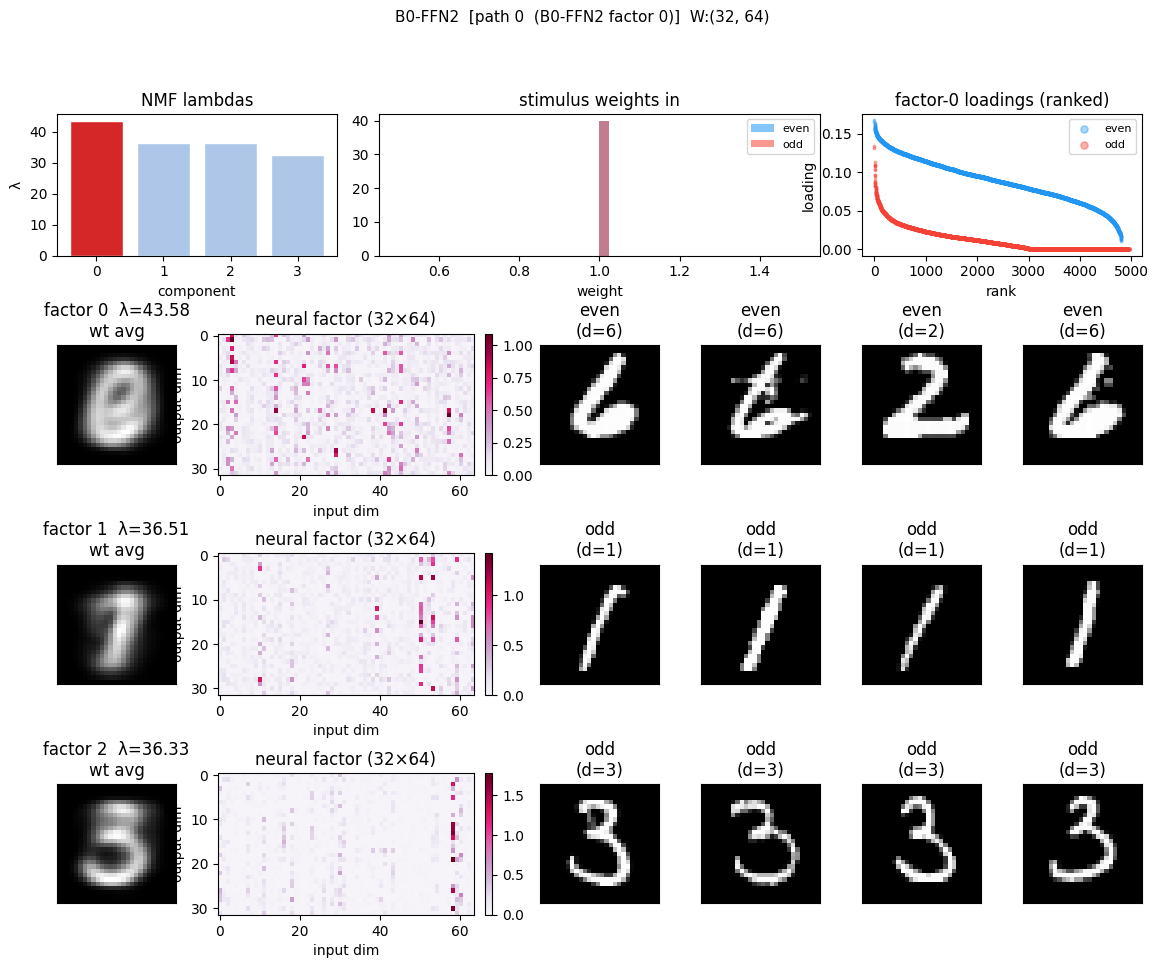

  B0-FFN2 [path 0  (B0-FFN2 factor 0)]: k*=4


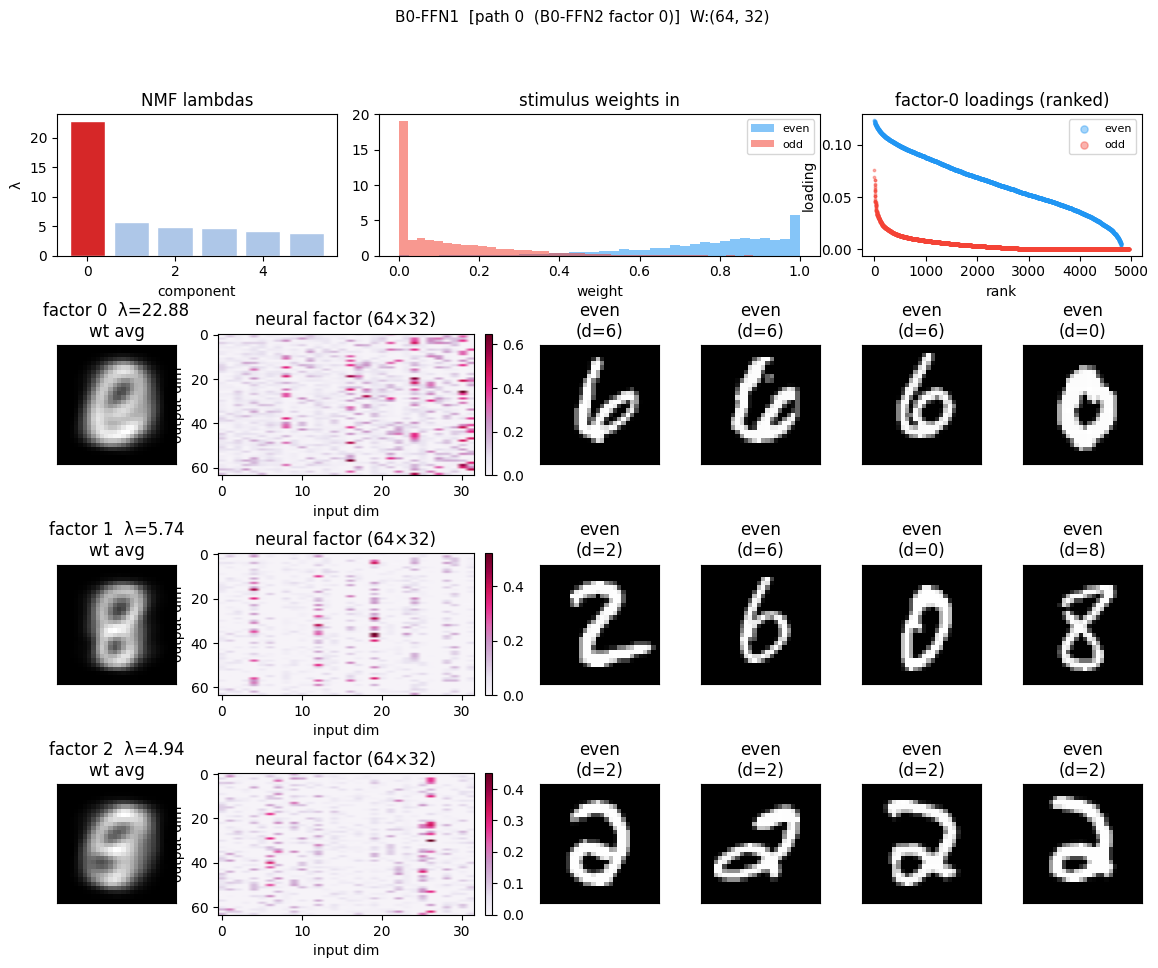

  B0-FFN1 [path 0  (B0-FFN2 factor 0)]: k*=6


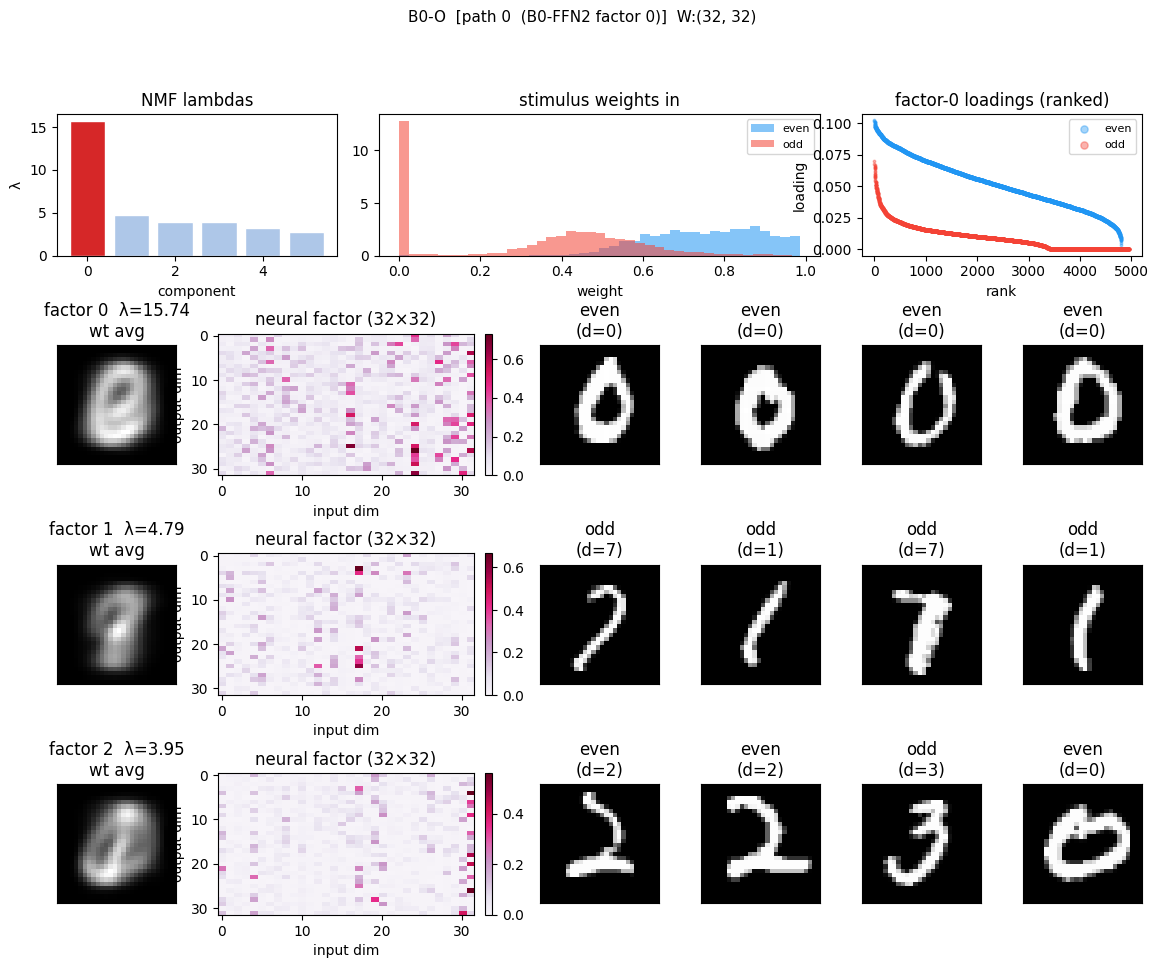

  B0-O [path 0  (B0-FFN2 factor 0)]: k*=6


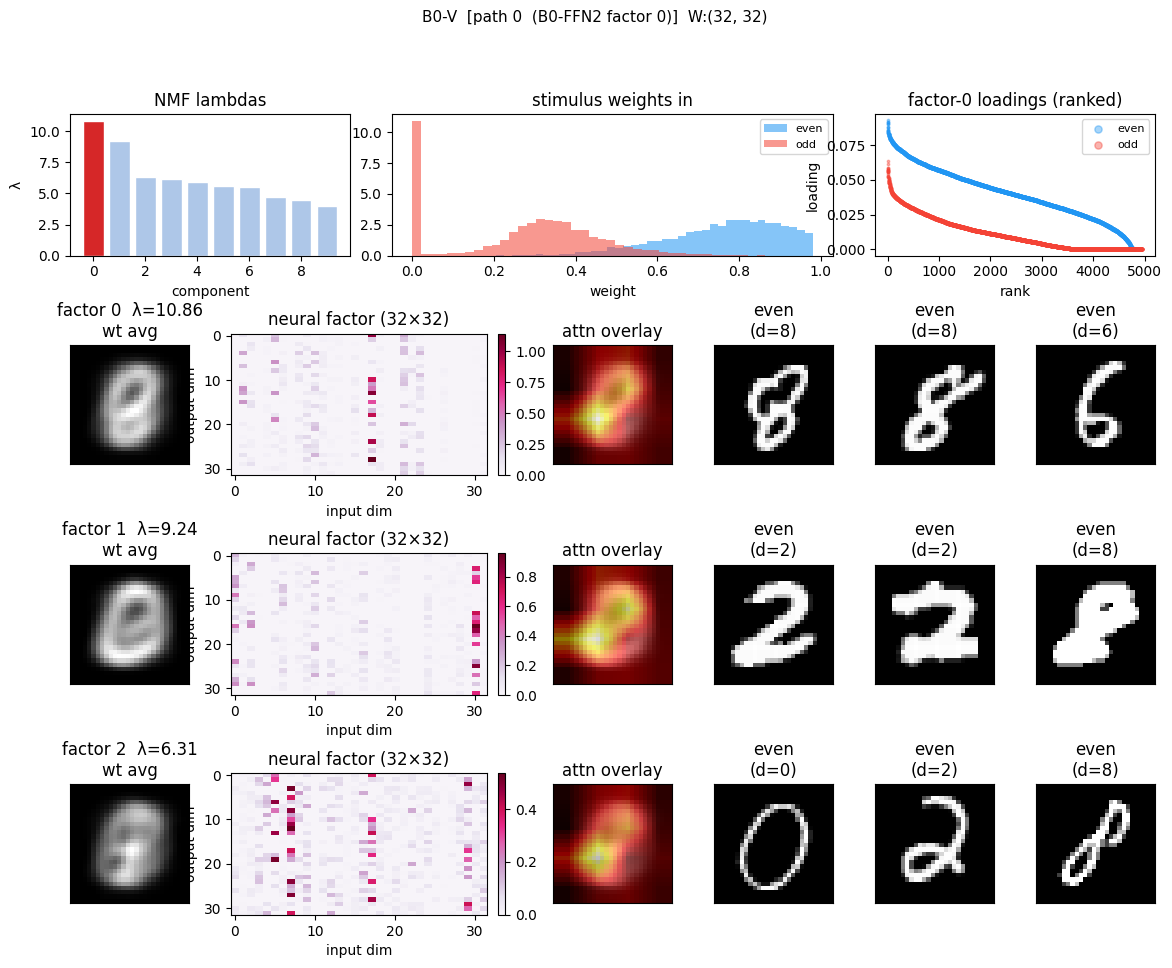

  B0-V [path 0  (B0-FFN2 factor 0)]: k*=10


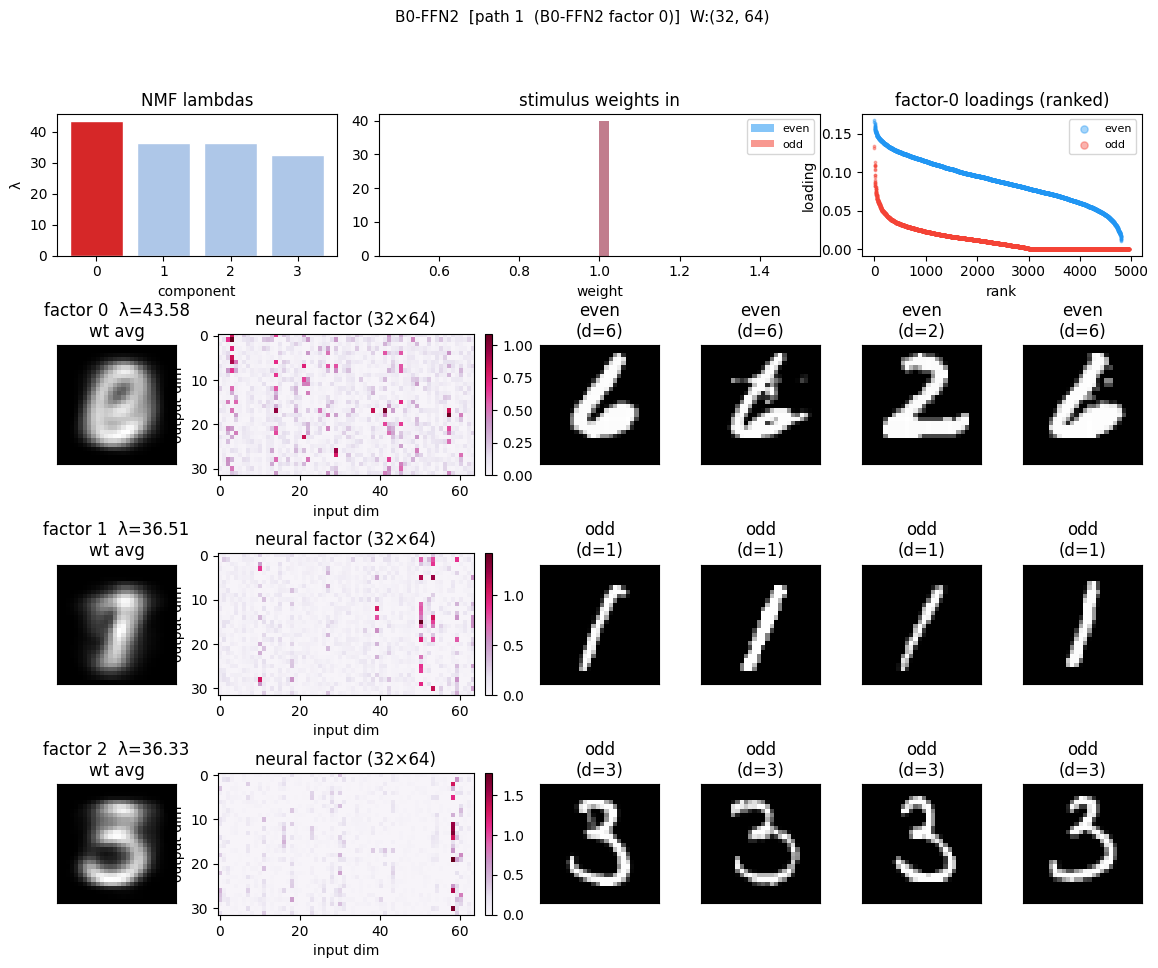

  B0-FFN2 [path 1  (B0-FFN2 factor 0)]: k*=4


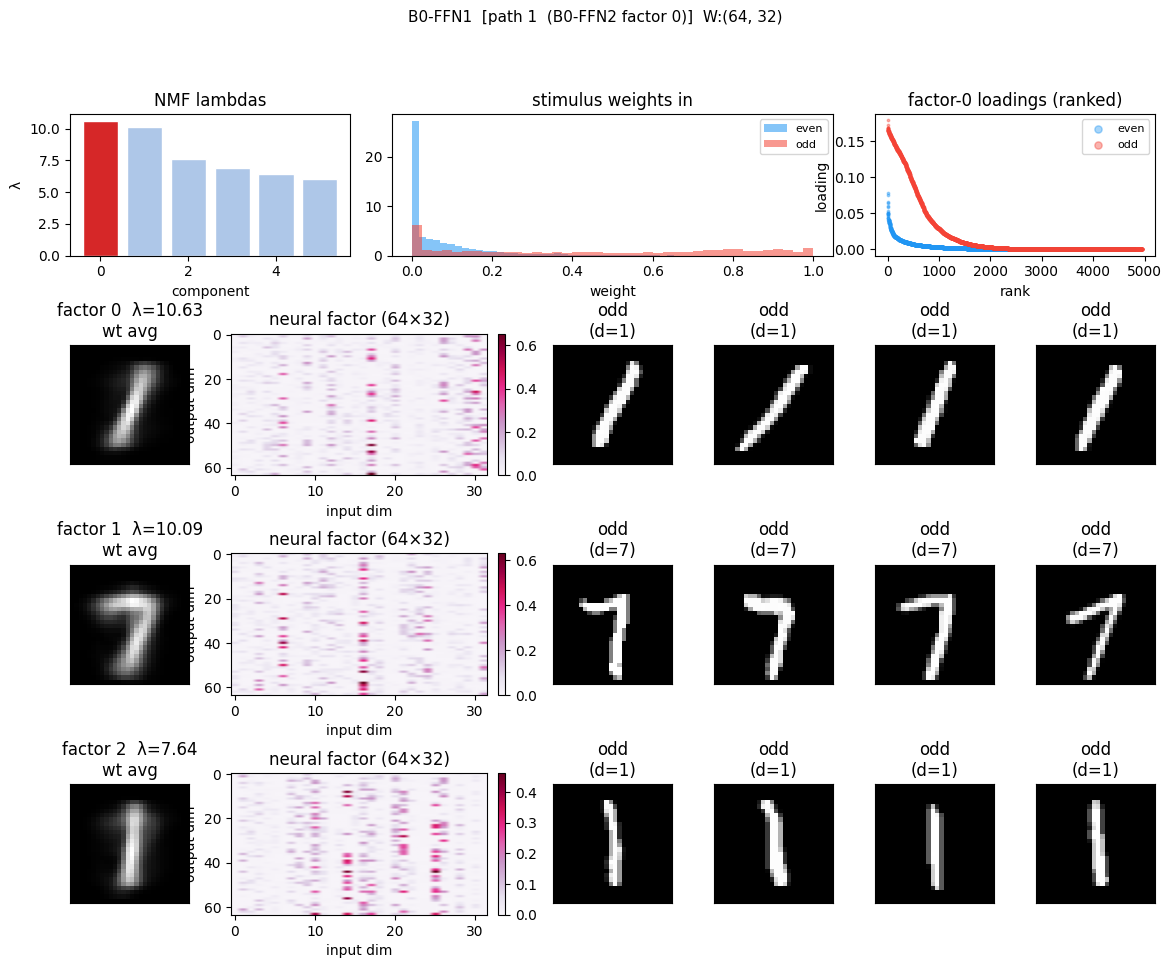

  B0-FFN1 [path 1  (B0-FFN2 factor 0)]: k*=6


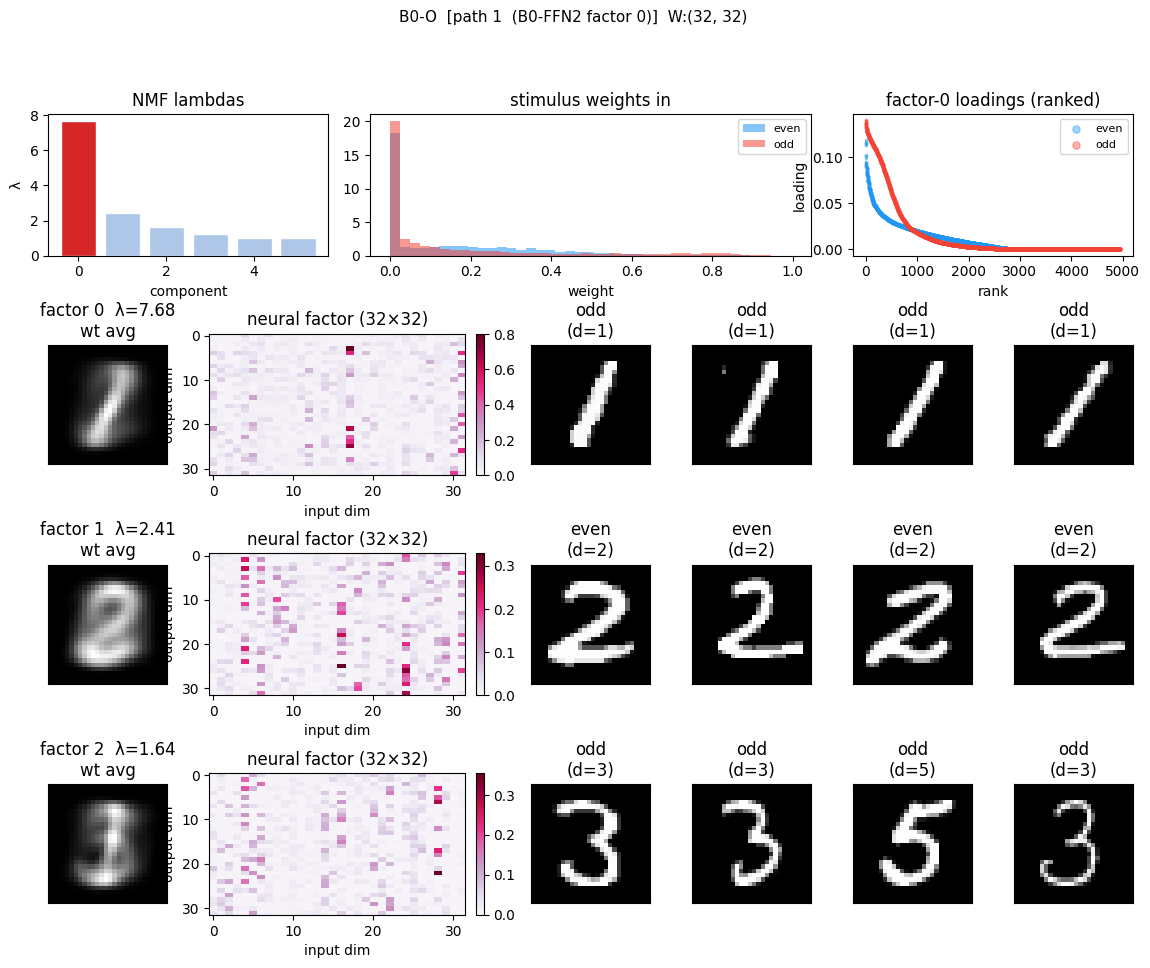

  B0-O [path 1  (B0-FFN2 factor 0)]: k*=6


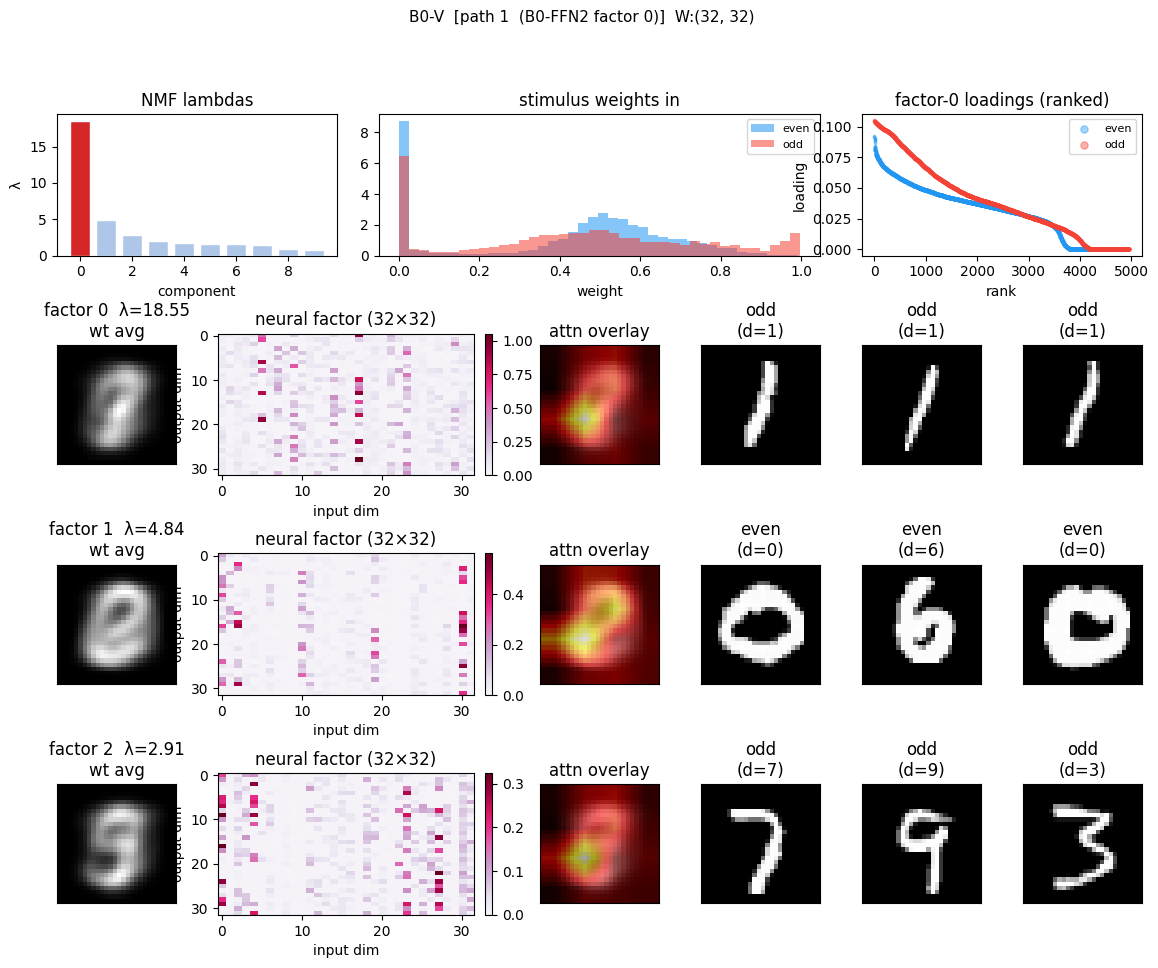

  B0-V [path 1  (B0-FFN2 factor 0)]: k*=10


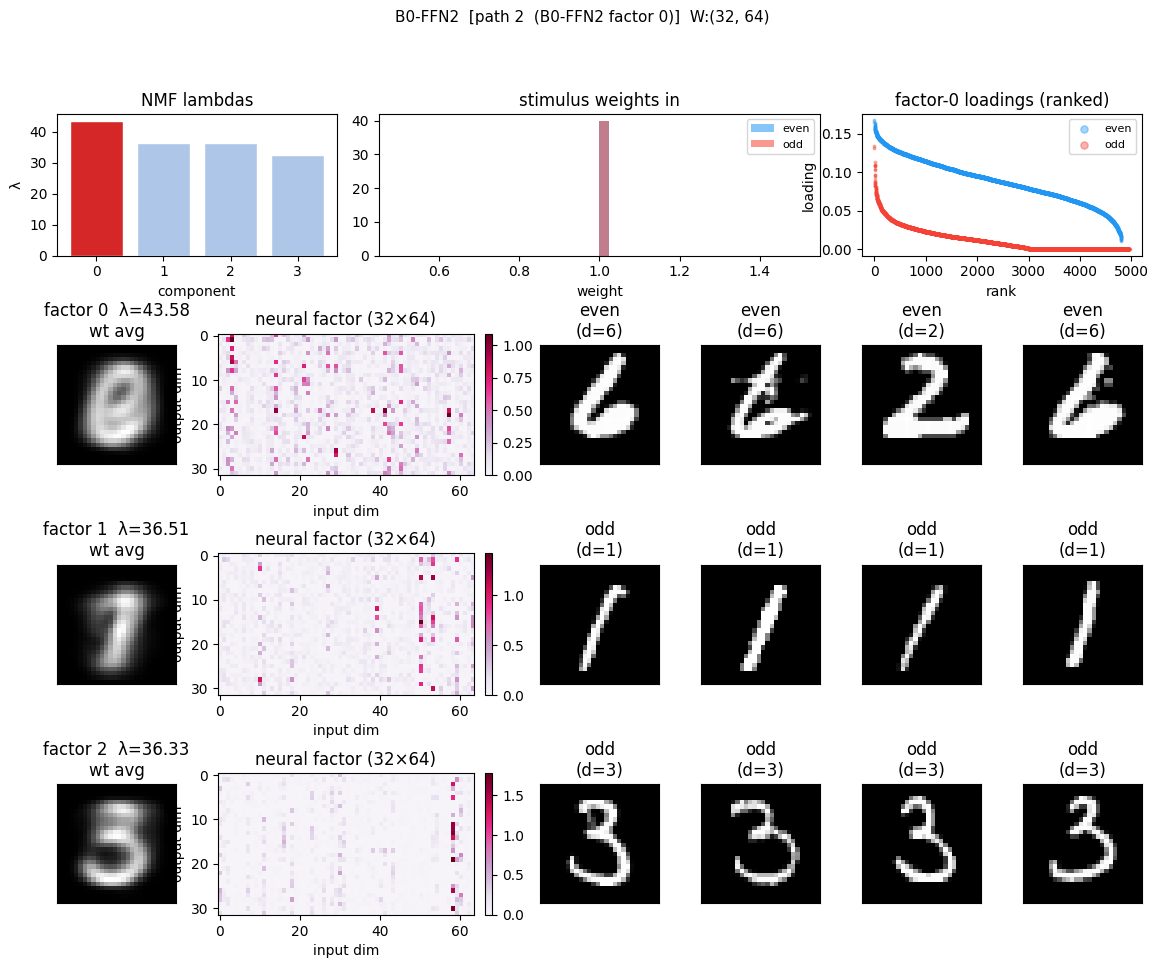

  B0-FFN2 [path 2  (B0-FFN2 factor 0)]: k*=4


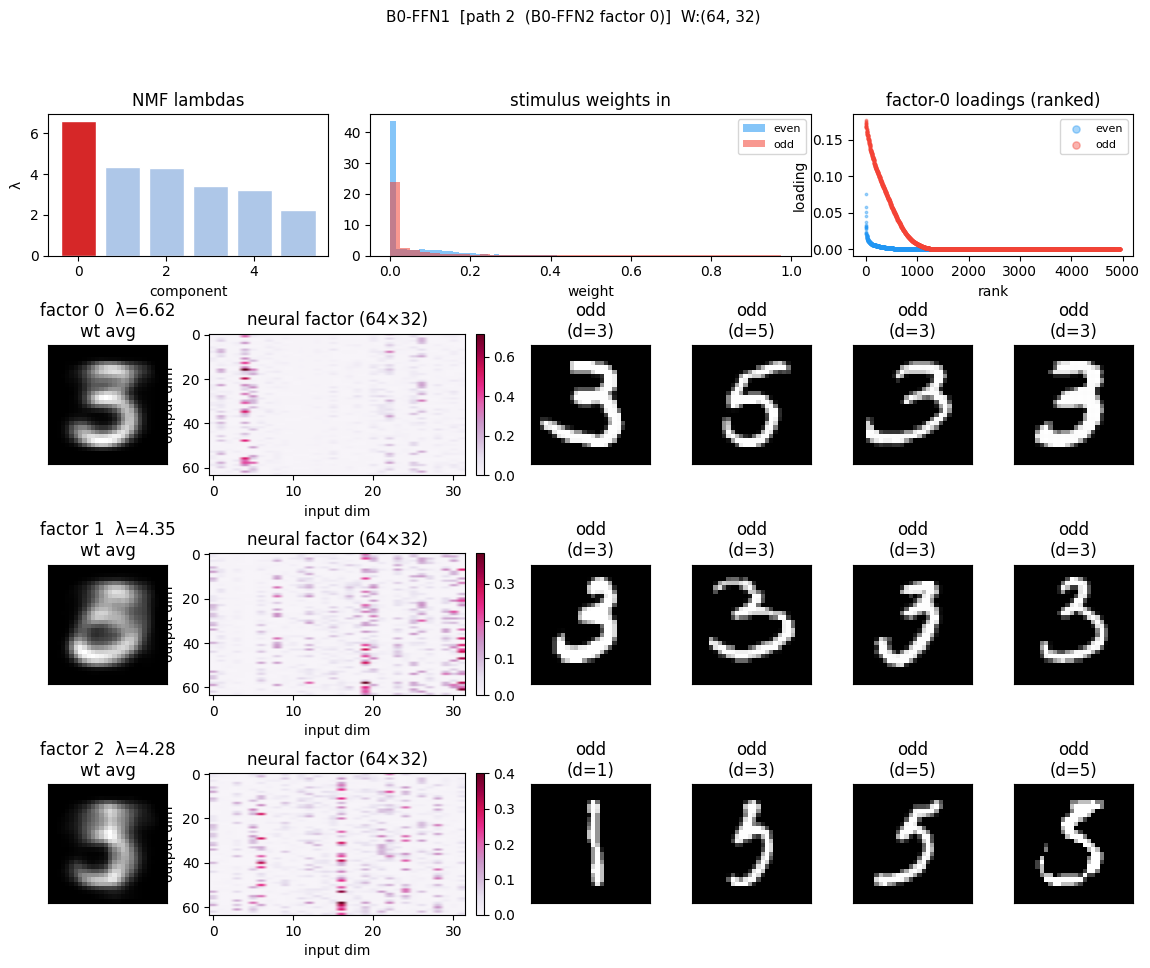

  B0-FFN1 [path 2  (B0-FFN2 factor 0)]: k*=6


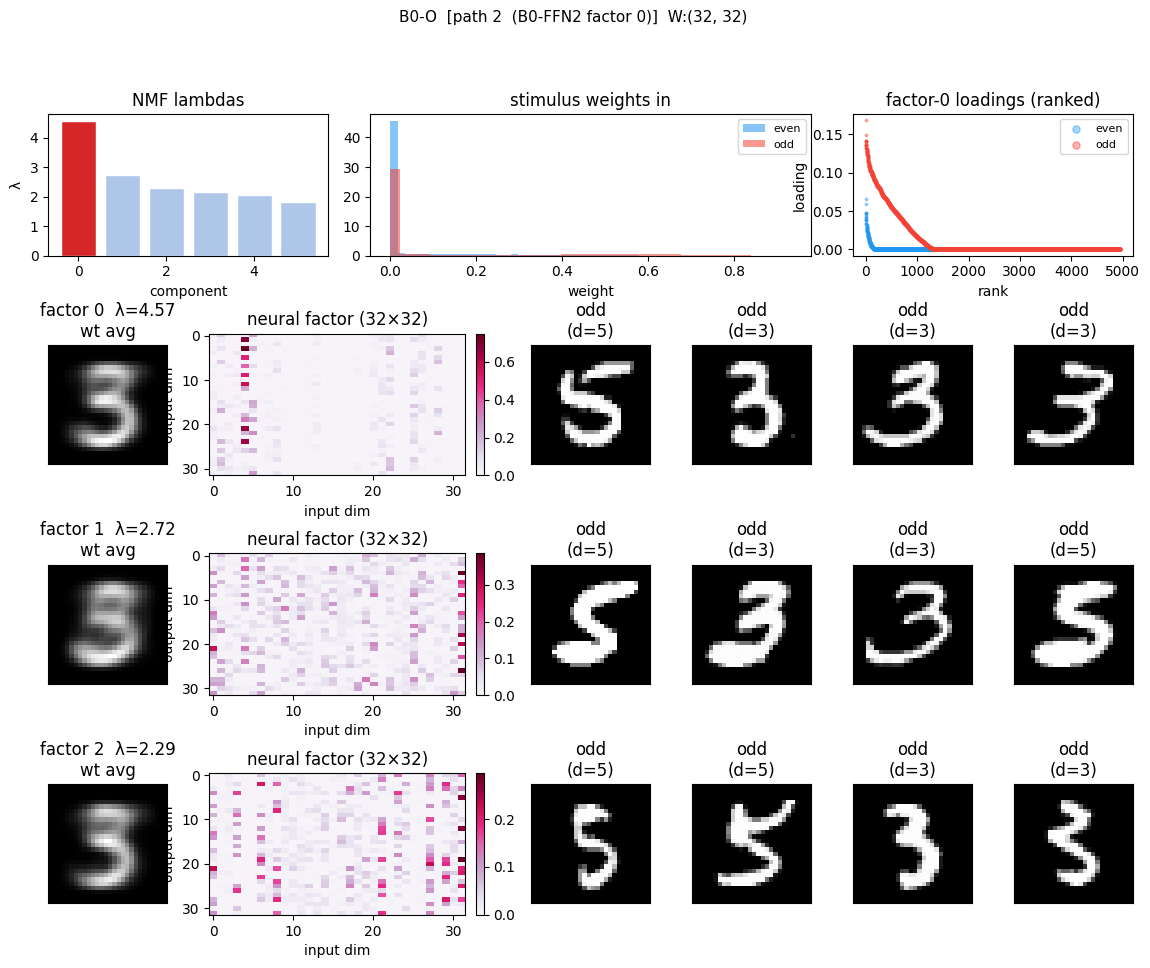

  B0-O [path 2  (B0-FFN2 factor 0)]: k*=6


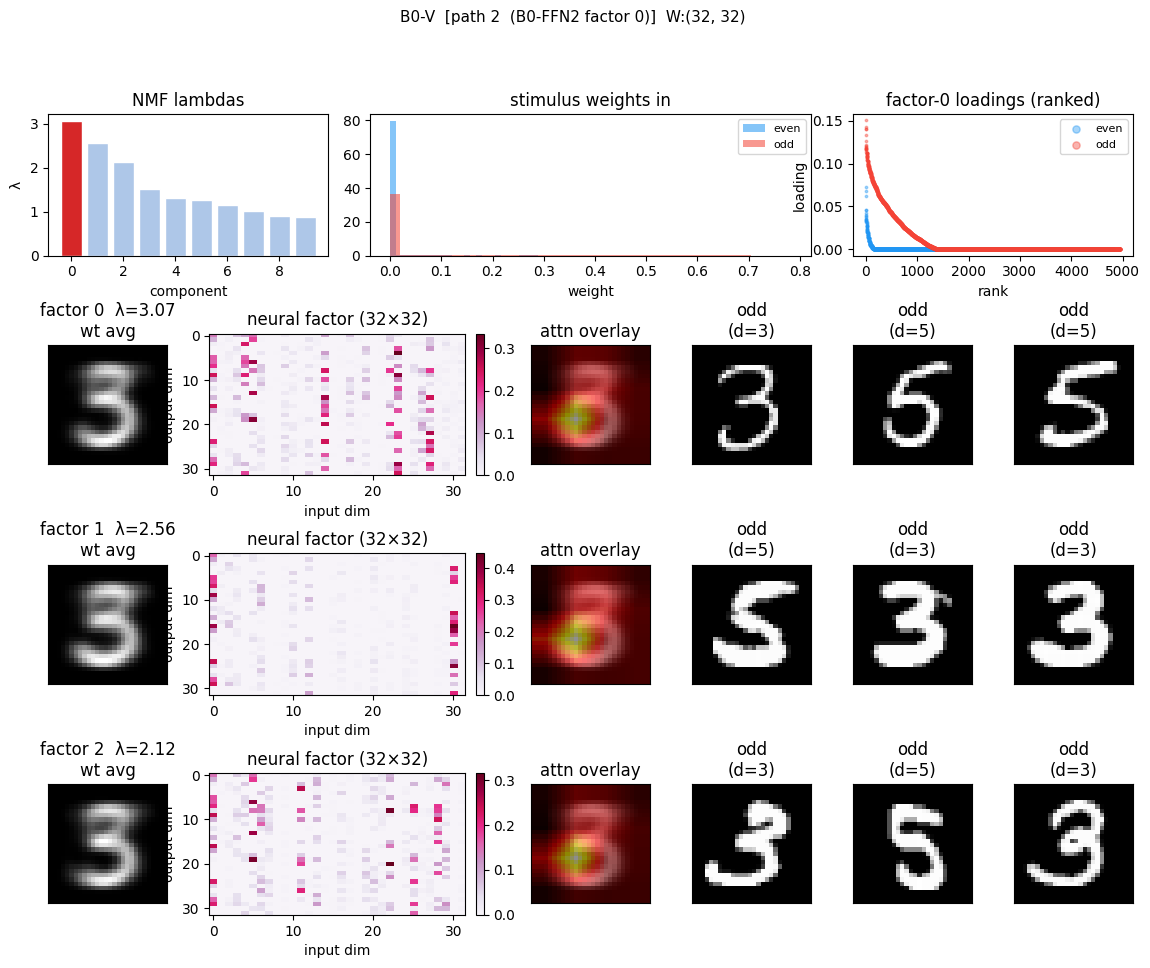

  B0-V [path 2  (B0-FFN2 factor 0)]: k*=10


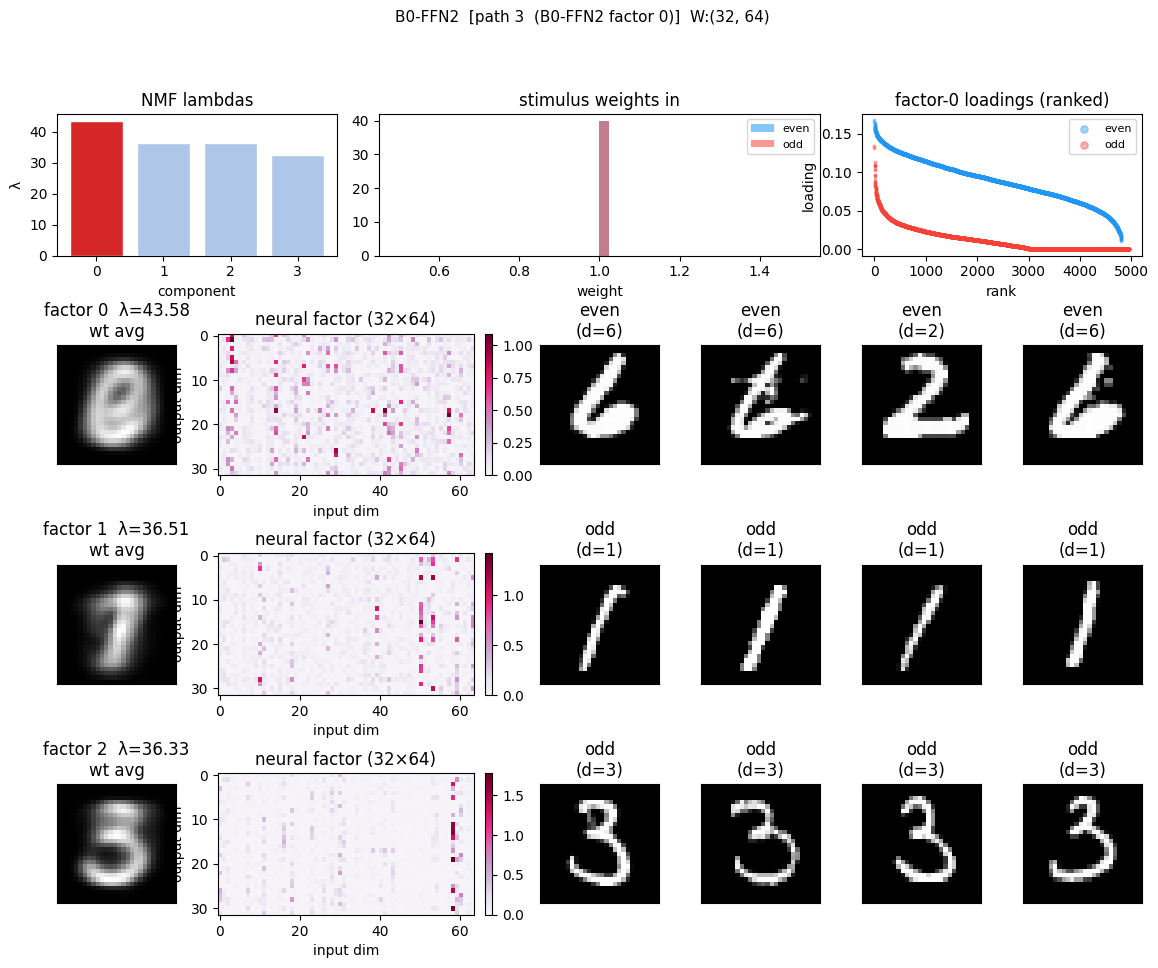

  B0-FFN2 [path 3  (B0-FFN2 factor 0)]: k*=4


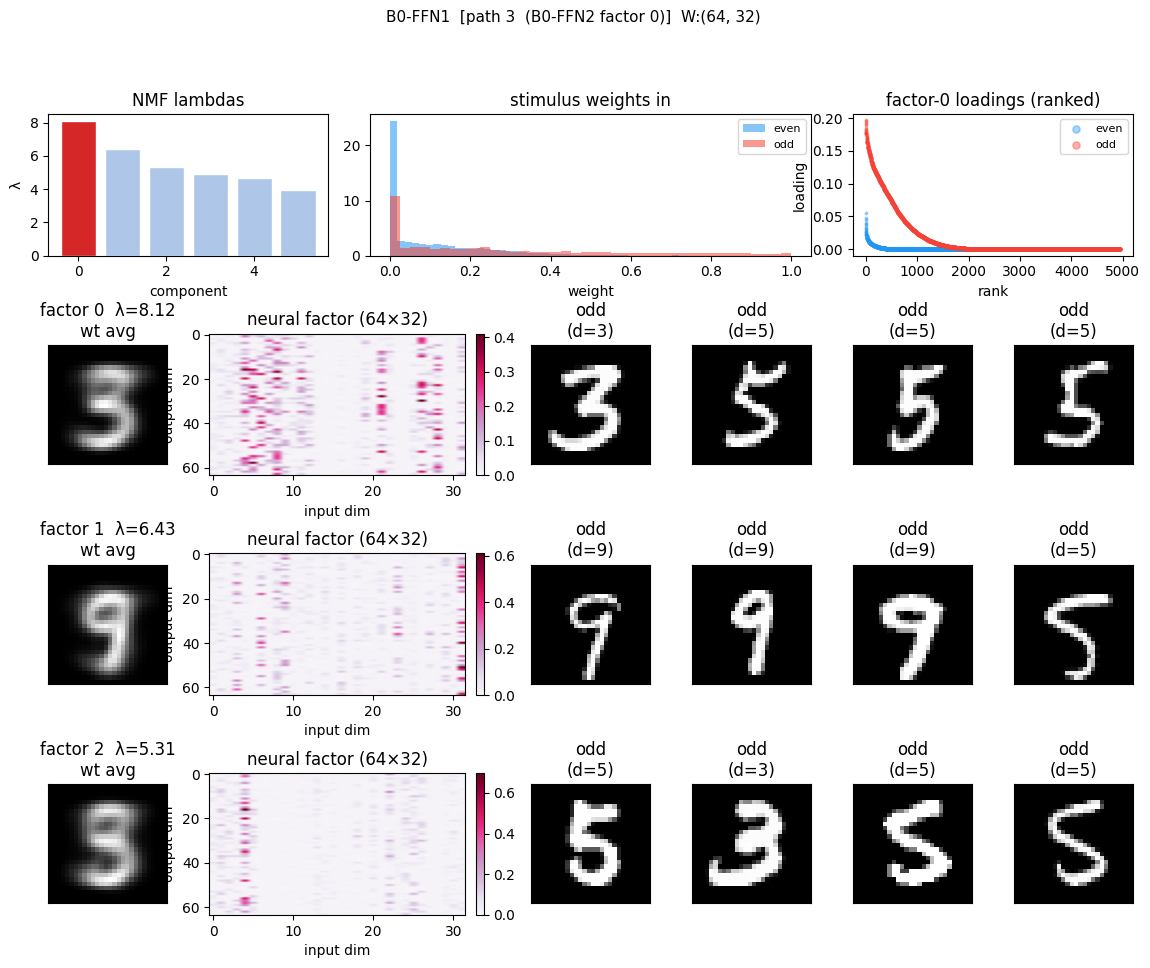

  B0-FFN1 [path 3  (B0-FFN2 factor 0)]: k*=6


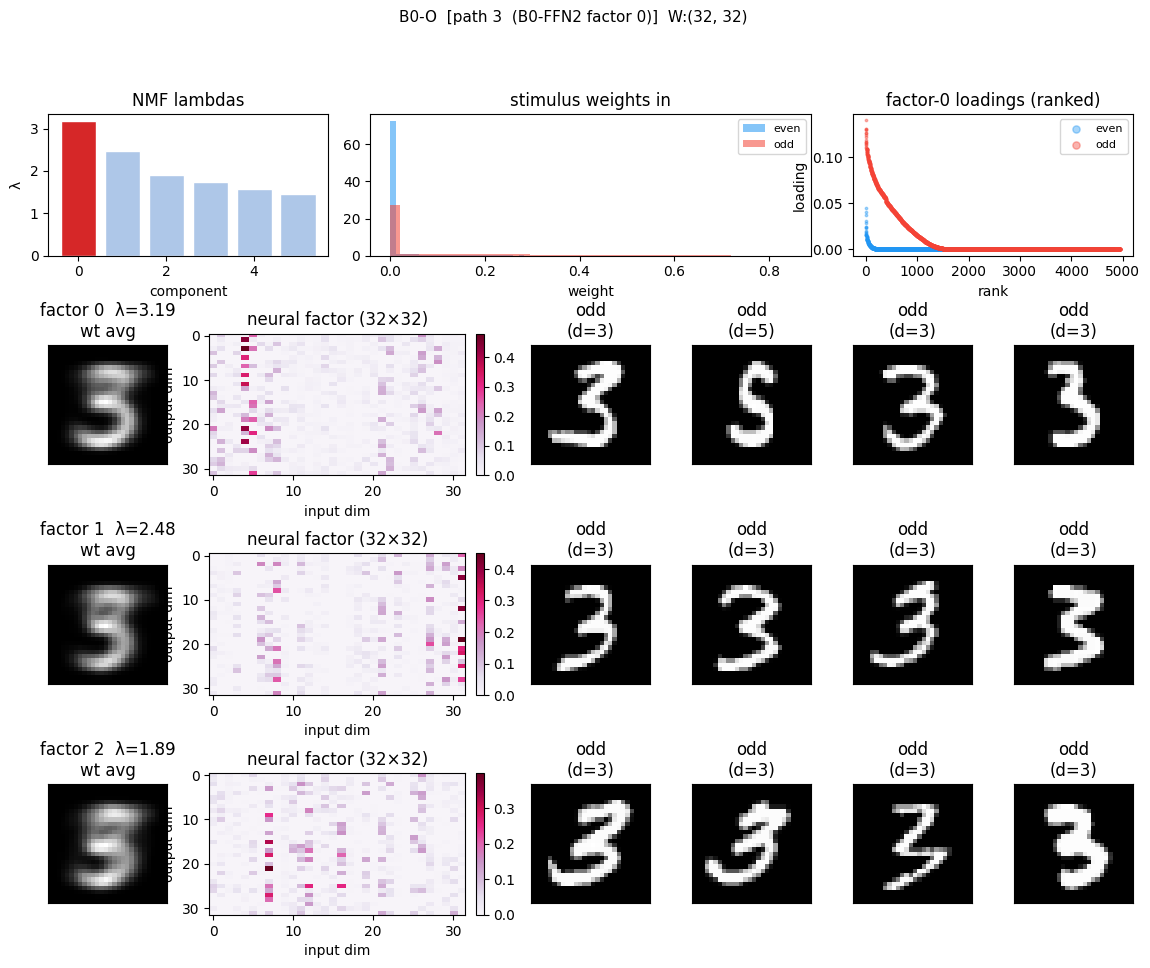

  B0-O [path 3  (B0-FFN2 factor 0)]: k*=6


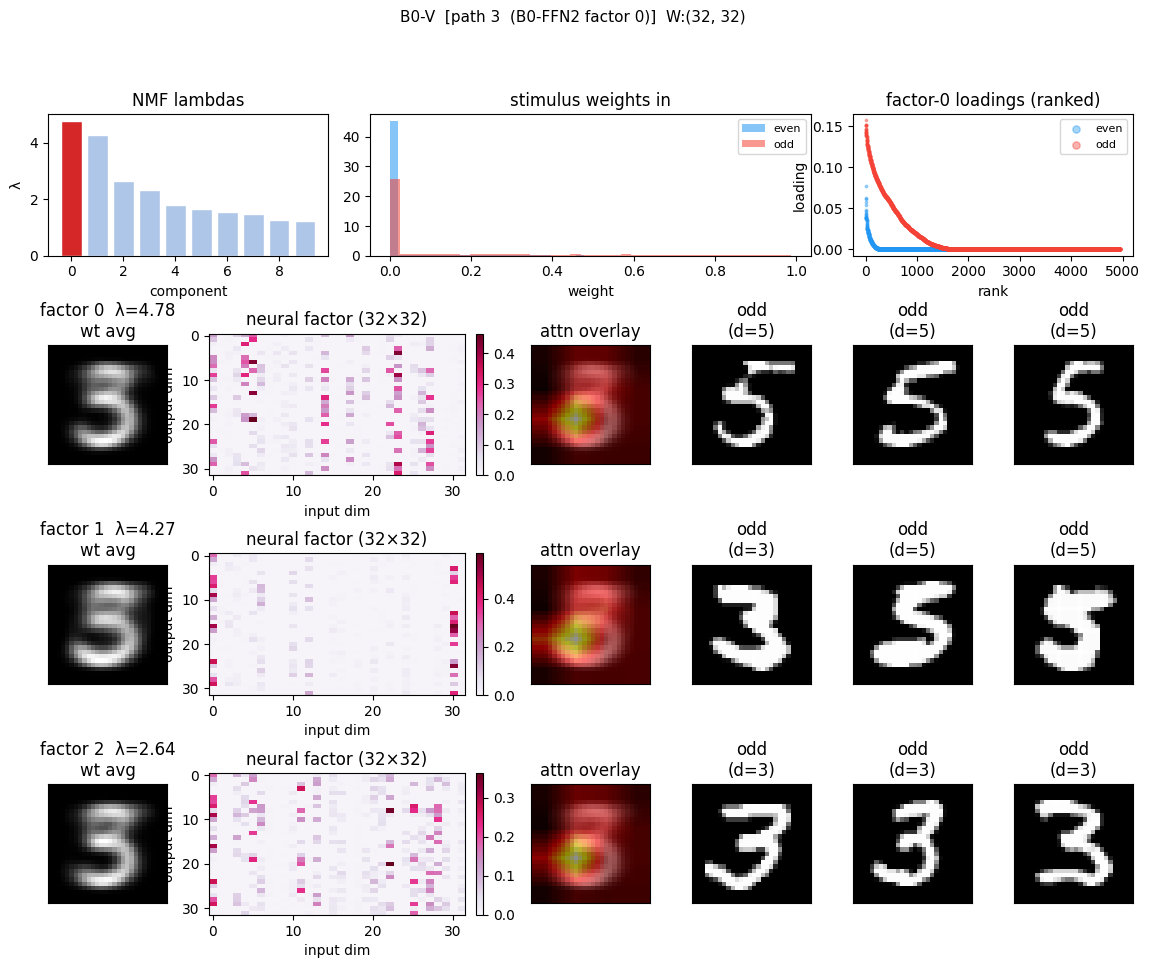

  B0-V [path 3  (B0-FFN2 factor 0)]: k*=10


In [ ]:
N_VIZ = 3  # factor rows per panel

for pi, path_nodes in enumerate(paths0):
    fi_last    = path_nodes[0]['factor_idx']
    path_label = f'path {pi}  (B0-FFN2 factor {fi_last})'

    for r in path_nodes:
        lname  = r['layer_name']
        ltype  = r['layer_type']
        img_f  = r['img_factors']       # (N, K)
        neu_f  = r['neural_factors']    # (n_out*n_in, K)
        lams   = r['lambdas']
        W      = r['W']
        n_out, n_in = W.shape
        n_show = min(N_VIZ, len(lams))
        has_attn = (ltype == 'attn') and ('attn_weights' in r)

        fig = plt.figure(figsize=(14, 2.6 * (n_show + 1)))
        fig.suptitle(f'{lname}  [{path_label}]  W:{W.shape}', fontsize=11)
        gs = gridspec.GridSpec(n_show + 1, 7, figure=fig, hspace=0.55, wspace=0.35)

        # Row 0: overview
        ax_lam = fig.add_subplot(gs[0, 0:2])
        ax_lam.bar(range(len(lams)), lams,
                   color=['#d62728'] + ['#aec7e8'] * (len(lams) - 1), edgecolor='white')
        ax_lam.set(title='NMF lambdas', xlabel='component', ylabel='λ')

        ax_sw = fig.add_subplot(gs[0, 2:5])
        sw = r['stimulus_weights_in']
        for cl, color, name in zip([0, 1], ['#2196F3', '#F44336'], CLASS_NAMES):
            ax_sw.hist(sw[targets0 == cl], bins=40, alpha=0.55,
                       density=True, color=color, label=name)
        ax_sw.set(title='stimulus weights in', xlabel='weight')
        ax_sw.legend(fontsize=8)

        ax_cls = fig.add_subplot(gs[0, 5:7])
        for cl, color, name in zip([0, 1], ['#2196F3', '#F44336'], CLASS_NAMES):
            mask = targets0 == cl
            ax_cls.scatter(np.arange(mask.sum()), np.sort(img_f[mask, 0])[::-1],
                           s=3, alpha=0.4, color=color, label=name)
        ax_cls.set(title='factor-0 loadings (ranked)', xlabel='rank', ylabel='loading')
        ax_cls.legend(markerscale=3, fontsize=8)

        # Factor rows
        for fi in range(n_show):
            coefs   = img_f[:, fi]
            w_norm  = coefs / (coefs.sum() + 1e-12)
            per_neu = neu_f[:, fi].reshape(n_out, n_in)

            ax_wav = fig.add_subplot(gs[fi + 1, 0])
            w_avg  = (w_norm[:, None, None] * images0[:, 0]).sum(0)
            ax_wav.imshow(w_avg, cmap='gray')
            ax_wav.set(title=f'factor {fi}  λ={lams[fi]:.2f}\nwt avg', xticks=[], yticks=[])

            ax_nf = fig.add_subplot(gs[fi + 1, 1:3])
            vmax  = np.abs(per_neu).max() or 1.0
            im    = ax_nf.imshow(per_neu, aspect='auto', cmap='PuRd', vmin=0, vmax=vmax)
            plt.colorbar(im, ax=ax_nf, fraction=0.046, pad=0.04)
            ax_nf.set(title=f'neural factor ({n_out}×{n_in})',
                      xlabel='input dim', ylabel='output dim')

            if has_attn:
                attn_patch = r['attn_weights'][:, 1:]   # (N, 16) drop CLS token
                avg_attn   = (w_norm[:, None] * attn_patch).sum(0)
                attn_grid  = avg_attn.reshape(4, 4)
                attn_up    = F.interpolate(
                    torch.tensor(attn_grid).float().unsqueeze(0).unsqueeze(0),
                    size=(28, 28), mode='bilinear', align_corners=False,
                ).squeeze().numpy()
                ax_attn = fig.add_subplot(gs[fi + 1, 3])
                ax_attn.imshow(w_avg, cmap='gray')
                ax_attn.imshow(attn_up, cmap='hot', alpha=0.55, vmin=0)
                ax_attn.set(title='attn overlay', xticks=[], yticks=[])
                img_col_start = 4
            else:
                img_col_start = 3

            top_idx = np.argsort(coefs)[::-1][:7 - img_col_start]
            for col_i, s_idx in enumerate(top_idx):
                col = img_col_start + col_i
                if col >= 7:
                    break
                ax_img = fig.add_subplot(gs[fi + 1, col])
                ax_img.imshow(images0[s_idx, 0], cmap='gray')
                ax_img.set(title=f'{CLASS_NAMES[targets0[s_idx]]}\n(d={digits0[s_idx]})',
                           xticks=[], yticks=[])

        fname = os.path.join(FIG_DIR, f'factor_panel_{lname.replace("-","")}_p{pi}.png')
        fig.savefig(fname, dpi=100, bbox_inches='tight')
        plt.show()
        print(f'  {lname} [{path_label}]: k*={len(lams)}')

4 attention (B0-V) nodes in tree


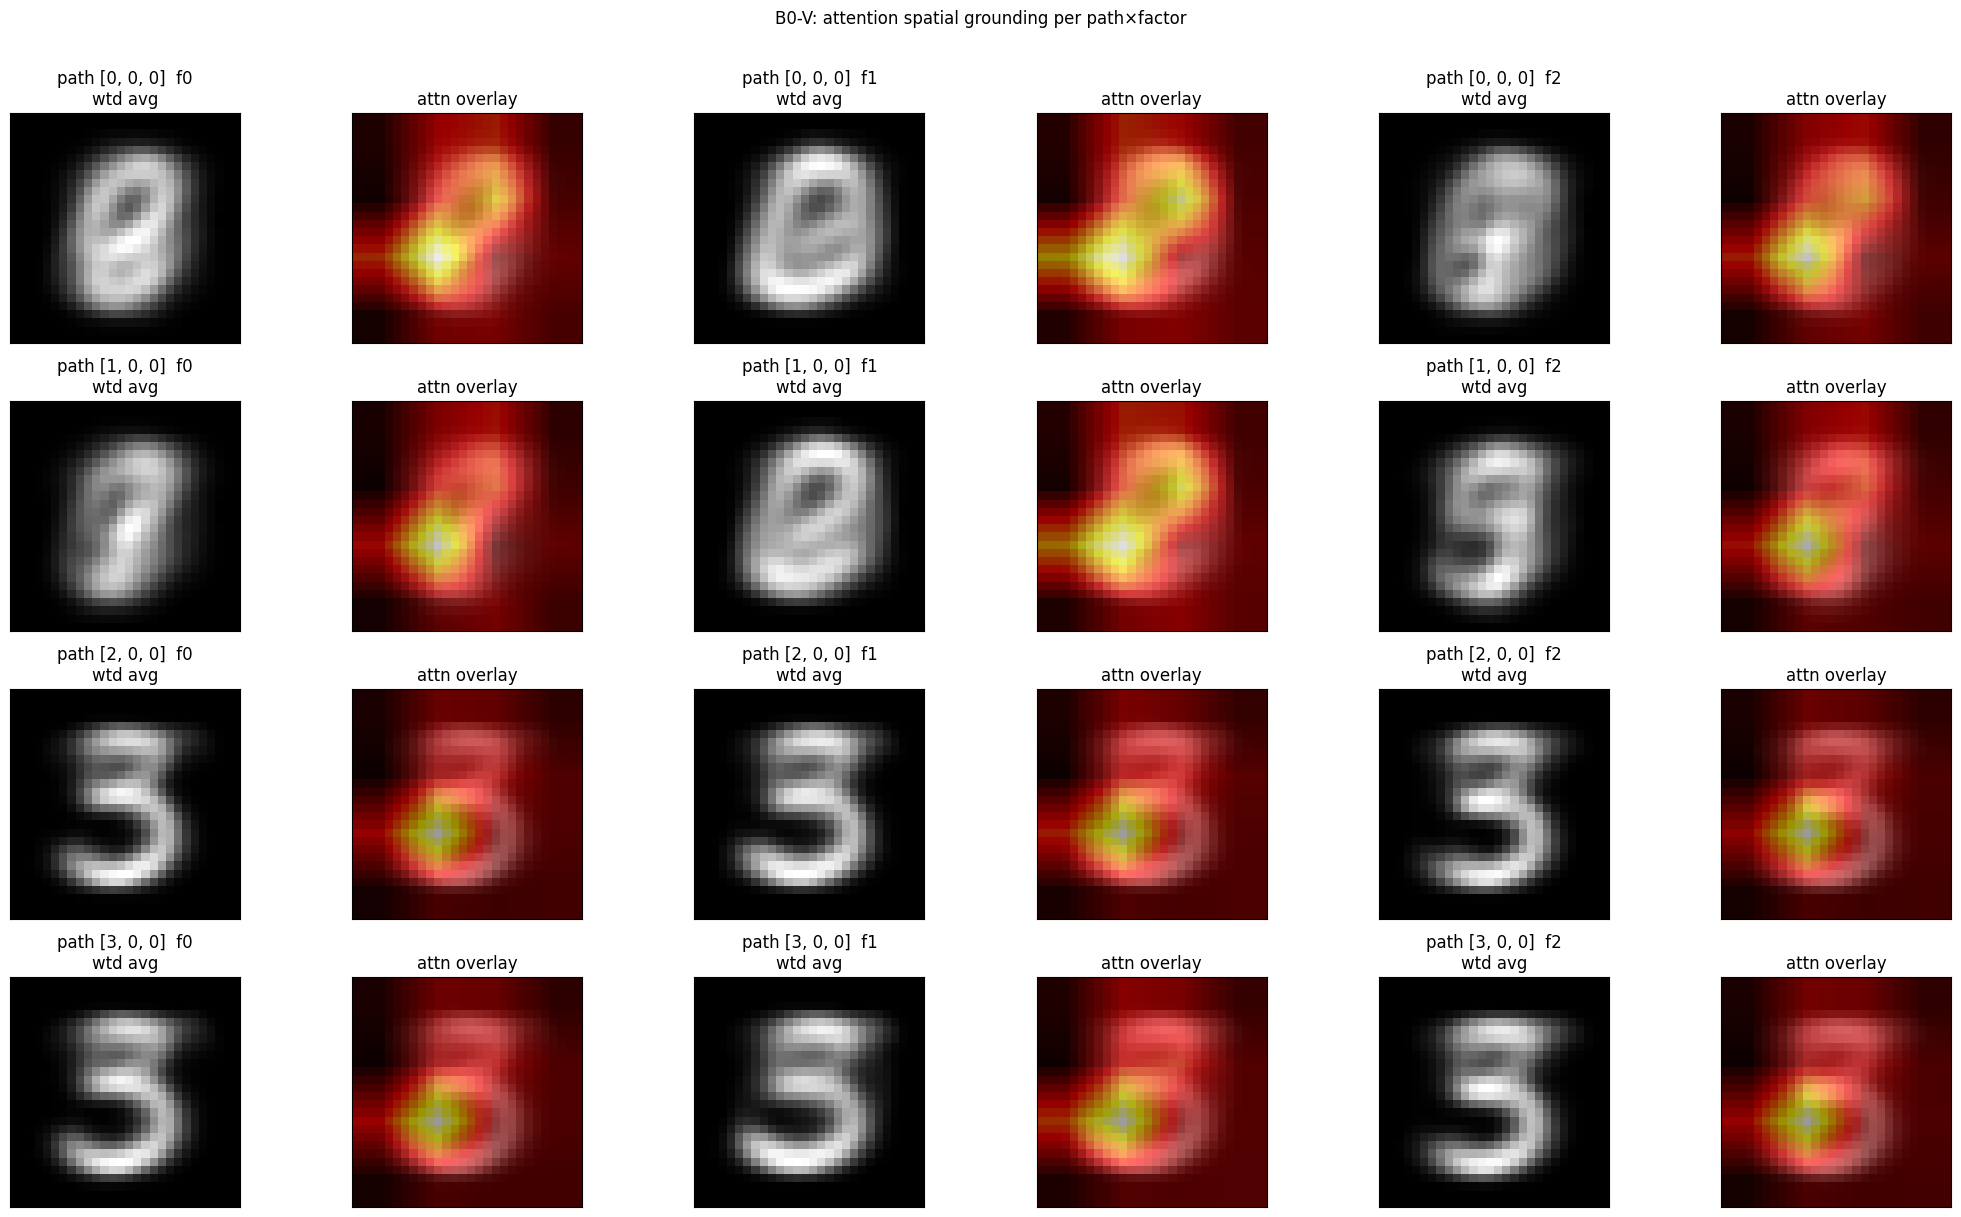

In [ ]:
# ── Attention spatial grounding ────────────────────────────────────────────────
# Project factor loadings back to 4×4 patch grid via factor-weighted attention scores.

def get_attn_nodes(root):
    """Return all B0-V nodes from the BFT tree."""
    nodes, queue = [], [root]
    while queue:
        n = queue.pop(0)
        if n['layer_type'] == 'attn':
            nodes.append(n)
        queue.extend(n['children'])
    return nodes

attn_nodes = get_attn_nodes(tree0)
print(f'{len(attn_nodes)} attention (B0-V) nodes in tree')

n_attn = len(attn_nodes)
n_factors_show = 3
fig, axes = plt.subplots(n_attn, n_factors_show * 2,
                          figsize=(3.5 * n_factors_show * 2, 3.0 * n_attn),
                          squeeze=False)

for row_i, attn_node in enumerate(attn_nodes):
    n_show = min(n_factors_show, attn_node['img_factors'].shape[1])
    attn_patch = attn_node['attn_weights'][:, 1:]   # (N, 16) — drop CLS self-attention

    for fi in range(n_show):
        coefs  = attn_node['img_factors'][:, fi]
        w_norm = coefs / (coefs.sum() + 1e-12)

        w_avg  = (w_norm[:, None, None] * images0[:, 0]).sum(0)
        avg_attn = (w_norm[:, None] * attn_patch).sum(0)
        attn_grid = avg_attn.reshape(4, 4)
        attn_up   = F.interpolate(
            torch.tensor(attn_grid).float().unsqueeze(0).unsqueeze(0),
            size=(28, 28), mode='bilinear', align_corners=False,
        ).squeeze().numpy()

        col_avg    = fi * 2
        col_overlay = fi * 2 + 1

        ax = axes[row_i, col_avg]
        ax.imshow(w_avg, cmap='gray')
        ax.set(title=f'path {attn_node["path"]}  f{fi}\nwtd avg', xticks=[], yticks=[])

        ax2 = axes[row_i, col_overlay]
        ax2.imshow(w_avg, cmap='gray')
        ax2.imshow(attn_up, cmap='hot', alpha=0.6, vmin=0)
        ax2.set(title='attn overlay', xticks=[], yticks=[])

    for fi in range(n_show, n_factors_show):
        axes[row_i, fi * 2].axis('off')
        axes[row_i, fi * 2 + 1].axis('off')

fig.suptitle('B0-V: attention spatial grounding per path×factor', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'attn_spatial_grounding.png'), dpi=120, bbox_inches='tight')
plt.show()

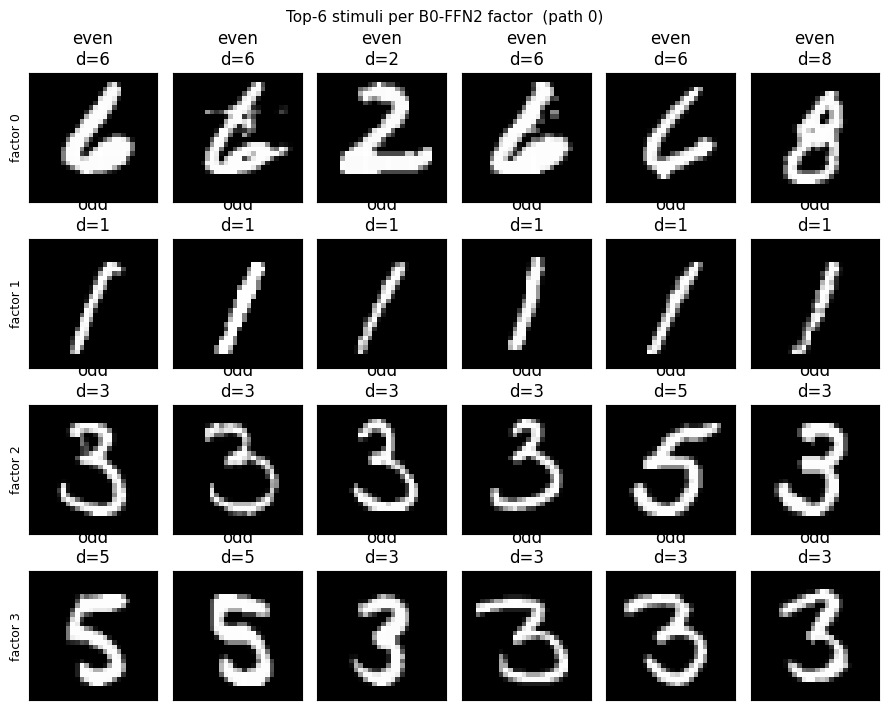

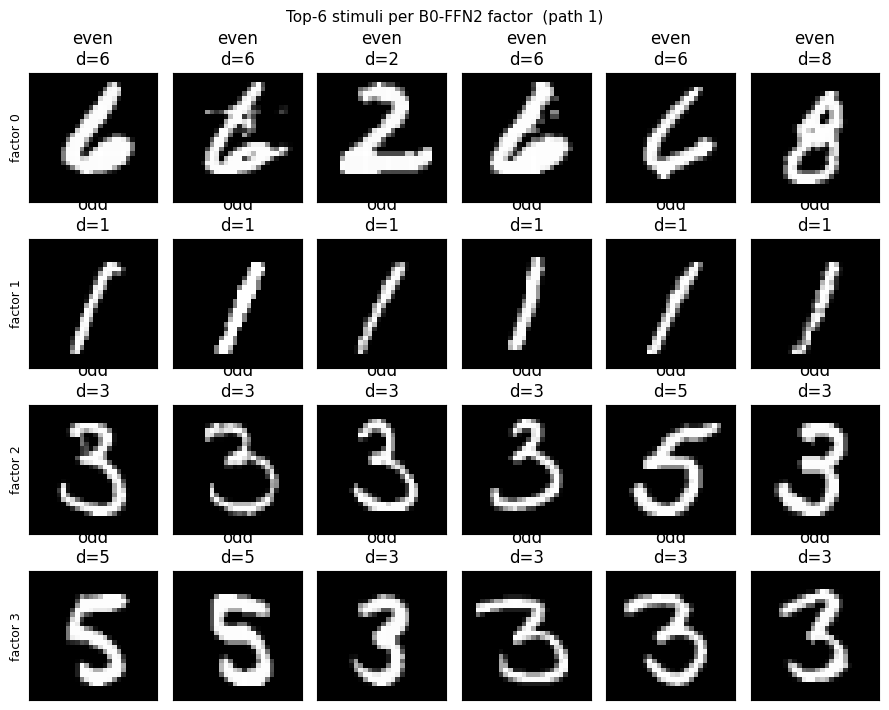

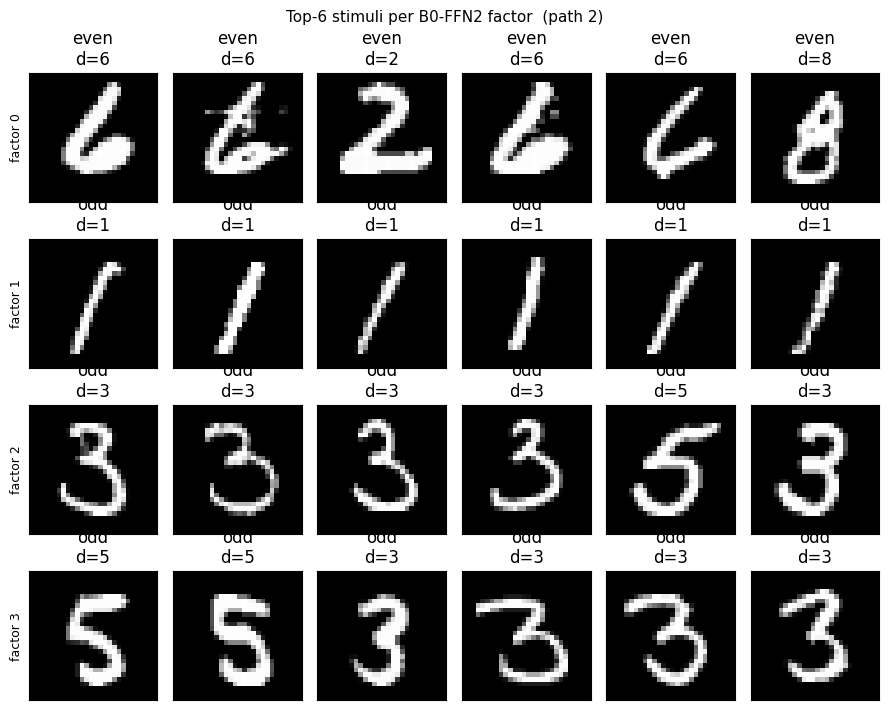

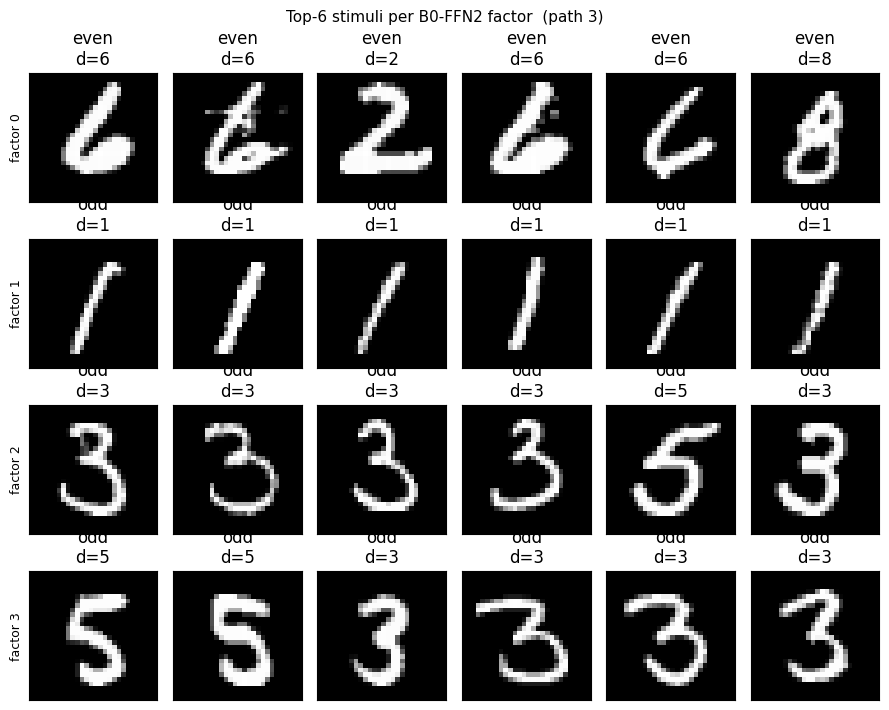

In [ ]:
# ── Top-N sample galleries for each path ──────────────────────────────────────
n_show_gallery = N_TOP_GALLERY

for pi, path_nodes in enumerate(paths0):
    root_node = path_nodes[0]  # B0-FFN2
    n_factors  = root_node['img_factors'].shape[1]
    n_show_f   = min(4, n_factors)

    fig, axes = plt.subplots(n_show_f, n_show_gallery,
                              figsize=(n_show_gallery * 1.5, n_show_f * 1.8))
    if n_show_f == 1:
        axes = axes[np.newaxis, :]

    for fi in range(n_show_f):
        coefs = root_node['img_factors'][:, fi]
        top_idx = np.argsort(coefs)[::-1][:n_show_gallery]
        for col, s_idx in enumerate(top_idx):
            ax = axes[fi, col]
            ax.imshow(images0[s_idx, 0], cmap='gray')
            ax.set(title=f'{CLASS_NAMES[targets0[s_idx]]}\nd={digits0[s_idx]}',
                   xticks=[], yticks=[])
        axes[fi, 0].set_ylabel(f'factor {fi}', fontsize=9)

    fig.suptitle(f'Top-{n_show_gallery} stimuli per B0-FFN2 factor  (path {pi})', fontsize=11)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'top_stimuli_p{pi}.png'), dpi=100, bbox_inches='tight')
    plt.show()

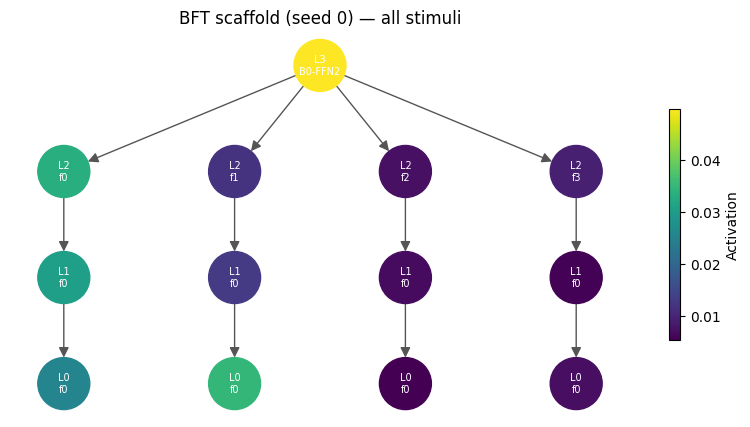

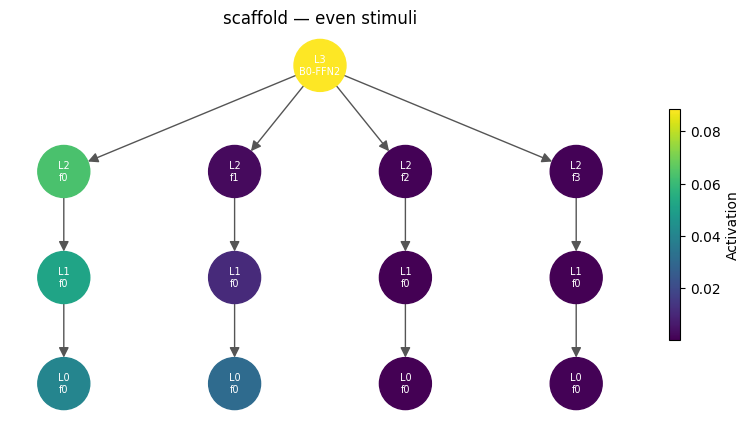

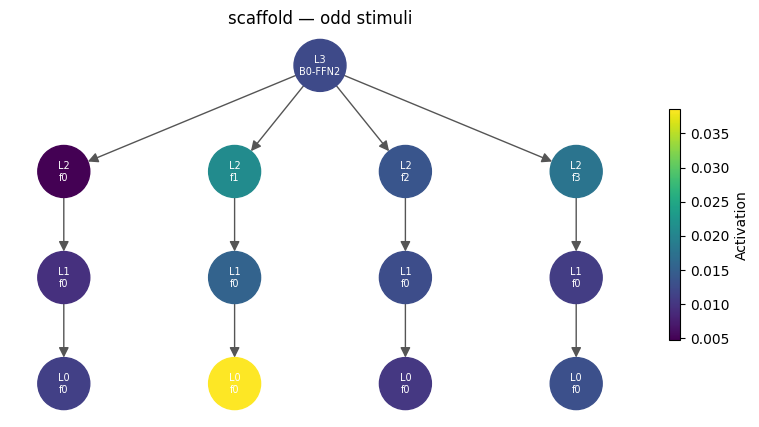

In [ ]:
# ── Scaffold graph ─────────────────────────────────────────────────────────────
tree_nodes0 = extract_tree_nodes(tree0)

fig, ax = plt.subplots(figsize=(10, 5))
node_acts = compute_node_activations(tree_nodes0, list(range(len(targets0))))
plot_factor_tree(tree_nodes0, node_acts, ax=ax, title='BFT scaffold (seed 0) — all stimuli')
fig.savefig(os.path.join(FIG_DIR, 'scaffold_all.png'), dpi=120, bbox_inches='tight')
plt.show()

for cl, cname in enumerate(CLASS_NAMES):
    cl_idx = np.where(targets0 == cl)[0]
    fig, ax = plt.subplots(figsize=(10, 5))
    node_acts_cl = compute_node_activations(tree_nodes0, cl_idx)
    plot_factor_tree(tree_nodes0, node_acts_cl, ax=ax, title=f'scaffold — {cname} stimuli')
    fig.savefig(os.path.join(FIG_DIR, f'scaffold_{cname}.png'), dpi=120, bbox_inches='tight')
    plt.show()

## §3  Ablation (all 5 seeds)

Local ablation helpers for TinyViT (standard `ablation_utils` depend on `model.linear_layer_indices()`,  
which is SimpleMLP-specific). We ablate the FFN and output-projection weights only.

In [ ]:
# Keys that define the ablatable linear weights in TinyViT
VIT_LINEAR_KEYS = [
    'block.attn.out_proj.weight',  # W_O (32×32)
    'block.ffn1.weight',           # (64×32)
    'block.ffn2.weight',           # (32×64)
    'head.weight',                 # (2×32)
]

# Map forward layer_idx → param key for NMF scoring
_LAYER_IDX_TO_KEY = {
    1: 'block.attn.out_proj.weight',
    2: 'block.ffn1.weight',
    3: 'block.ffn2.weight',
}


def vit_score_nmf(path_nodes):
    """NMF importance: {param_key: (n_out, n_in) array}."""
    scores = {}
    for node in path_nodes:
        key = _LAYER_IDX_TO_KEY.get(node['layer_idx'])
        if key is None:
            continue
        W = node['W']
        n_out, n_in = W.shape
        importance = np.zeros((n_out, n_in))
        for k in range(node['neural_factors'].shape[1]):
            nf = node['neural_factors'][:, k].reshape(n_out, n_in)
            importance += node['lambdas'][k] * nf
        scores[key] = importance
    return scores


def vit_score_magnitude(model):
    """Magnitude importance: {param_key: |W|}."""
    params = dict(model.named_parameters())
    return {key: np.abs(params[key].data.cpu().numpy()) for key in VIT_LINEAR_KEYS}


def vit_ablate(model, scores, frac, method='top', seed=42):
    """Zero the top-fraction of weights by score, return a deep copy."""
    m = copy.deepcopy(model)
    params = dict(m.named_parameters())
    for key, imp in scores.items():
        flat_imp = imp.flatten()
        n_abl = max(1, int(len(flat_imp) * frac))
        if method == 'top':
            idx = np.argsort(flat_imp)[::-1][:n_abl]
        elif method == 'bottom':
            idx = np.argsort(flat_imp)[:n_abl]
        elif method == 'magnitude':
            pw = np.abs(params[key].data.cpu().numpy().flatten())
            idx = np.argsort(pw)[::-1][:n_abl]
        elif method == 'random':
            rng = np.random.default_rng(seed)
            idx = rng.choice(len(flat_imp), n_abl, replace=False)
        else:
            raise ValueError(method)
        with torch.no_grad():
            params[key].data.view(-1)[np.ascontiguousarray(idx)] = 0.0
    return m


def eval_per_class_vit(model, loader, device):
    """Return per-class accuracy dict {class_idx: float}."""
    model.eval()
    correct = {c: 0 for c in range(N_CLASSES)}
    total   = {c: 0 for c in range(N_CLASSES)}
    with torch.no_grad():
        for imgs, digits in loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digits)
            preds  = model(imgs.to(device)).argmax(1).cpu()
            for c in range(N_CLASSES):
                mask = labels == c
                correct[c] += (preds[mask] == labels[mask]).sum().item()
                total[c]   += mask.sum().item()
    return {c: correct[c] / total[c] if total[c] > 0 else 0.0 for c in range(N_CLASSES)}


base_acc = eval_per_class_vit(model0, test_loader, DEVICE)
print('Baseline per-class accuracy (seed 0):')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {base_acc[c]:.4f}')

Baseline per-class accuracy (seed 0):
  even: 0.9752
  odd: 0.9767


In [ ]:
# ── Cache BFT for all 5 seeds ──────────────────────────────────────────────────
trees_all = [tree0]
acts_all  = [acts0]

for s in range(1, 5):
    cache_f = os.path.join(CACHE_ROOT, f'bft_seed{s}.pkl')
    if USE_CACHED and os.path.exists(cache_f):
        with open(cache_f, 'rb') as f:
            tree_s = pickle.load(f)
        print(f'Loaded BFT seed{s} from cache.')
    else:
        acts_s, _, _, _ = collect_vit_activations(models[s], test_loader, DEVICE)
        D = EMBED_DIM
        W_V_s  = models[s].block.attn.in_proj_weight[2*D:, :].detach().cpu().numpy()
        W_O_s  = models[s].block.attn.out_proj.weight.detach().cpu().numpy()
        W_f1_s = models[s].block.ffn1.weight.detach().cpu().numpy()
        W_f2_s = models[s].block.ffn2.weight.detach().cpu().numpy()
        ld_s = [
            {'type': 'attn', 'name': 'B0-V',    'weight': W_V_s,  'input_fmap': acts_s['attn_in'],      'attn_weights': acts_s['attn_w']},
            {'type': 'fc',   'name': 'B0-O',    'weight': W_O_s,  'input_fmap': acts_s['attn_out_cls']},
            {'type': 'fc',   'name': 'B0-FFN1', 'weight': W_f1_s, 'input_fmap': acts_s['ffn1_in']},
            {'type': 'fc',   'name': 'B0-FFN2', 'weight': W_f2_s, 'input_fmap': acts_s['ffn2_in']},
        ]
        print(f'Running BFT seed{s} ...')
        tree_s = bft(ld_s, k_max=K_MAX, n_branches=N_BRANCHES,
                     stimulus_threshold=STIM_THRESHOLD, weighting='img_selectivity',
                     verbose=0, n_jobs=3)
        with open(cache_f, 'wb') as f:
            pickle.dump(tree_s, f)
        print(f'  seed{s} done, cached.')
    trees_all.append(tree_s)
    # re-collect acts for ablation if needed
    acts_all.append(None)  # placeholder — loaded only for BFT

print(f'Trees ready: {len(trees_all)}')

Running BFT seed1 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed1 done, cached.
Running BFT seed2 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed2 done, cached.
Running BFT seed3 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed3 done, cached.
Running BFT seed4 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed4 done, cached.
Trees ready: 5


In [ ]:
# ── Comparative ablation sweep (4 methods, seed 0) ────────────────────────────
ABLATION_METHODS = ['nmf_top', 'nmf_bottom', 'magnitude', 'random']
ABLATION_COLORS  = {'nmf_top': '#d62728', 'nmf_bottom': '#ff7f0e',
                    'magnitude': '#2ca02c', 'random': '#9467bd'}

# Collect overall accuracy per method per fraction
sweep_results = {m: [] for m in ABLATION_METHODS}

path_nodes0 = paths0[0]  # primary path
nmf_scores  = vit_score_nmf(path_nodes0)
mag_scores  = vit_score_magnitude(model0)

for frac in ABLATION_FRACS:
    for method in ABLATION_METHODS:
        if method == 'nmf_top':
            m_abl = vit_ablate(model0, nmf_scores, frac, method='top')
        elif method == 'nmf_bottom':
            m_abl = vit_ablate(model0, nmf_scores, frac, method='bottom')
        elif method == 'magnitude':
            m_abl = vit_ablate(model0, mag_scores, frac, method='magnitude')
        elif method == 'random':
            m_abl = vit_ablate(model0, nmf_scores, frac, method='random')

        pc = eval_per_class_vit(m_abl, test_loader, DEVICE)
        sweep_results[method].append(np.mean(list(pc.values())))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
fracs_pct = [f * 100 for f in ABLATION_FRACS]
for method in ABLATION_METHODS:
    ax.plot(fracs_pct, sweep_results[method], marker='o',
            color=ABLATION_COLORS[method], label=method)
ax.axhline(np.mean(list(base_acc.values())), ls='--', color='gray', label='baseline')
ax.set(title='Comparative ablation sweep (seed 0)',
       xlabel='% weights ablated', ylabel='mean test accuracy')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ablation_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

ValueError: At least one stride in the given numpy array is negative, and tensors with negative strides are not currently supported. (You can probably work around this by making a copy of your array  with array.copy().) 

In [ ]:
# ── Causal circuit ablation (binary: even vs odd) ─────────────────────────────
# For each class, run BFT with class-specific stimuli, then ablate.
# Measure drop in target class vs bystander class.

N_CAUSAL_SEEDS = 5
CAUSAL_FRAC    = 0.15

specificity_rows = []   # [(class, seed, target_drop, bystander_drop)]

for s in range(N_CAUSAL_SEEDS):
    model_s = models[s]
    acts_s, images_s, targets_s, digits_s = collect_vit_activations(model_s, test_loader, DEVICE)
    D_s = EMBED_DIM
    base_pc_s = eval_per_class_vit(model_s, test_loader, DEVICE)

    for cl in range(N_CLASSES):
        cl_mask = targets_s == cl
        ld_cl = [
            {'type': 'attn', 'name': 'B0-V',
             'weight': models[s].block.attn.in_proj_weight[2*D_s:, :].detach().cpu().numpy(),
             'input_fmap': acts_s['attn_in'][cl_mask],
             'attn_weights': acts_s['attn_w'][cl_mask]},
            {'type': 'fc', 'name': 'B0-O',
             'weight': models[s].block.attn.out_proj.weight.detach().cpu().numpy(),
             'input_fmap': acts_s['attn_out_cls'][cl_mask]},
            {'type': 'fc', 'name': 'B0-FFN1',
             'weight': models[s].block.ffn1.weight.detach().cpu().numpy(),
             'input_fmap': acts_s['ffn1_in'][cl_mask]},
            {'type': 'fc', 'name': 'B0-FFN2',
             'weight': models[s].block.ffn2.weight.detach().cpu().numpy(),
             'input_fmap': acts_s['ffn2_in'][cl_mask]},
        ]

        tree_cl = bft(ld_cl, k_max=K_MAX, n_branches=[1, 1, 1, 2],
                      stimulus_threshold=STIM_THRESHOLD, weighting='img_selectivity',
                      verbose=0, n_jobs=3)
        path_cl = get_all_paths(tree_cl)[0]
        scores_cl = vit_score_nmf(path_cl)

        m_abl = vit_ablate(model_s, scores_cl, CAUSAL_FRAC, method='top')
        pc_abl = eval_per_class_vit(m_abl, test_loader, DEVICE)

        bystander = 1 - cl
        target_drop    = base_pc_s[cl]        - pc_abl[cl]
        bystander_drop = base_pc_s[bystander] - pc_abl[bystander]
        specificity_rows.append((cl, s, target_drop, bystander_drop))
        print(f'  seed{s} class={CLASS_NAMES[cl]:4s}  '
              f'target_drop={target_drop:+.3f}  bystander_drop={bystander_drop:+.3f}')

print('\nWilcoxon test (target > bystander drop):')
for cl in range(N_CLASSES):
    rows = [r for r in specificity_rows if r[0] == cl]
    td = [r[2] for r in rows]
    bd = [r[3] for r in rows]
    stat, pval = wilcoxon(td, bd, alternative='greater')
    print(f'  {CLASS_NAMES[cl]}: stat={stat:.2f}  p={pval:.4f}')

In [ ]:
# Specificity plot: target drop vs bystander drop per class
fig, axes = plt.subplots(1, N_CLASSES, figsize=(4 * N_CLASSES, 4), sharey=True)
for ax_i, cl in enumerate(range(N_CLASSES)):
    rows = [r for r in specificity_rows if r[0] == cl]
    td   = [r[2] for r in rows]
    bd   = [r[3] for r in rows]
    ax   = axes[ax_i]
    ax.scatter(td, bd, c='#1565C0', s=60, zorder=3, label='seeds')
    lim = max(abs(np.min([td, bd])), abs(np.max([td, bd]))) + 0.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='identity')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set(title=f'{CLASS_NAMES[cl]} circuit  (frac={CAUSAL_FRAC})',
           xlabel='target class drop', ylabel='bystander drop')
    ax.legend(fontsize=8)

fig.suptitle('Causal circuit specificity (above diagonal = target-specific)', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'causal_specificity.png'), dpi=120, bbox_inches='tight')
plt.show()

## §4  New Stimuli via NNLS

`project_stimuli_onto_tree` re-uses the fixed NMF bases from seed 0's BFT tree  
and projects new stimuli onto them via backward-weighted NNLS.  
For the attention layer (B0-V) the input must be supplied as a dict  
`{'x_tokens': (N,T,d), 'attn_weights': (N,T)}`.

In [ ]:
def collect_vit_layer_inputs(model, loader, device, only_correct=True, max_per_class=None):
    """Collect layer inputs for new_layer_inputs passed to project_stimuli_onto_tree.

    Returns (new_layer_inputs, images, targets, digits) where new_layer_inputs is
    a list of 4 items in FORWARD order:
      [0] dict {'x_tokens': (N,17,32), 'attn_weights': (N,17)}   — attn layer
      [1] ndarray (N, 32)  — B0-O fc layer
      [2] ndarray (N, 32)  — B0-FFN1
      [3] ndarray (N, 64)  — B0-FFN2
    """
    model.eval()
    acts = {'attn_in': [], 'attn_w': [], 'attn_out': [], 'ffn1_in': [], 'ffn2_in': []}
    images, targets_l, digits_l = [], [], []
    counts = {c: 0 for c in range(N_CLASSES)}

    with torch.no_grad():
        for imgs, digs in loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digs)
            logits = model(imgs, capture=True)
            preds  = logits.argmax(1).cpu()

            if only_correct:
                mask = (preds == labels)
            else:
                mask = torch.ones(len(labels), dtype=torch.bool)

            if max_per_class is not None:
                for c in range(N_CLASSES):
                    if counts[c] >= max_per_class:
                        mask &= ~(labels == c)

            if not mask.any():
                continue

            blk = model.block
            acts['attn_in'].append(blk._attn_in[mask].cpu().numpy())
            acts['attn_w'].append(blk._attn_w[mask].mean(1)[:, 0, :].cpu().numpy())
            acts['attn_out'].append(blk._attn_out[mask, 0].cpu().numpy())
            acts['ffn1_in'].append(blk._ffn1_in[mask, 0].cpu().numpy())
            acts['ffn2_in'].append(blk._ffn2_in[mask, 0].cpu().numpy())
            images.append(imgs[mask].cpu().numpy())
            targets_l.append(labels[mask].numpy())
            digits_l.append(digs[mask.cpu()].numpy())
            for c in range(N_CLASSES):
                counts[c] += (labels[mask] == c).sum().item()

    for k in acts:
        acts[k] = np.concatenate(acts[k], axis=0)

    new_layer_inputs = [
        {'x_tokens': acts['attn_in'], 'attn_weights': acts['attn_w']},  # idx 0 = B0-V
        acts['attn_out'],    # idx 1 = B0-O
        acts['ffn1_in'],     # idx 2 = B0-FFN1
        acts['ffn2_in'],     # idx 3 = B0-FFN2
    ]
    images    = np.concatenate(images,    axis=0)
    targets_l = np.concatenate(targets_l, axis=0)
    digits_l  = np.concatenate(digits_l,  axis=0)
    return new_layer_inputs, images, targets_l, digits_l


def collect_vit_ood_inputs(model, loader, device, n_max=2000):
    """Collect activations for OOD data (no label filtering)."""
    model.eval()
    acts = {'attn_in': [], 'attn_w': [], 'attn_out': [], 'ffn1_in': [], 'ffn2_in': []}
    images_l = []
    n_seen = 0

    with torch.no_grad():
        for imgs, _ in loader:
            if n_seen >= n_max:
                break
            imgs = imgs.to(device)
            _ = model(imgs, capture=True)
            blk = model.block
            b = min(len(imgs), n_max - n_seen)
            acts['attn_in'].append(blk._attn_in[:b].cpu().numpy())
            acts['attn_w'].append(blk._attn_w[:b].mean(1)[:, 0, :].cpu().numpy())
            acts['attn_out'].append(blk._attn_out[:b, 0].cpu().numpy())
            acts['ffn1_in'].append(blk._ffn1_in[:b, 0].cpu().numpy())
            acts['ffn2_in'].append(blk._ffn2_in[:b, 0].cpu().numpy())
            images_l.append(imgs[:b].cpu().numpy())
            n_seen += b

    for k in acts:
        acts[k] = np.concatenate(acts[k], axis=0)
    new_layer_inputs = [
        {'x_tokens': acts['attn_in'], 'attn_weights': acts['attn_w']},
        acts['attn_out'], acts['ffn1_in'], acts['ffn2_in'],
    ]
    images_l = np.concatenate(images_l, axis=0)
    return new_layer_inputs, images_l


print('NNLS helpers defined.')

In [ ]:
# ── Round-trip test ────────────────────────────────────────────────────────────
# Project the same test samples used to build tree0; NNLS loadings should
# correlate strongly with the original BFT img_factors.

new_inputs_test, _, _, _ = collect_vit_layer_inputs(model0, test_loader, DEVICE, only_correct=True)
tree_rt = project_stimuli_onto_tree(tree0, new_inputs_test)

# Compare root-node img_factors
orig_f = tree0['img_factors']           # (N_test, K)
nnls_f = tree_rt['img_factors']         # (N_rt, K)
N_cmp = min(len(orig_f), len(nnls_f))
K_cmp = min(orig_f.shape[1], nnls_f.shape[1])
corrs = [np.corrcoef(orig_f[:N_cmp, k], nnls_f[:N_cmp, k])[0, 1] for k in range(K_cmp)]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(K_cmp), corrs, color='#1565C0')
ax.axhline(0.8, ls='--', color='gray', label='r=0.8')
ax.set(title='Round-trip correlation (B0-FFN2 root factors)',
       xlabel='factor', ylabel='Pearson r')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'round_trip.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Round-trip correlations:', [f'{r:.3f}' for r in corrs])

In [ ]:
# ── In-distribution projection (train set) ────────────────────────────────────
new_inputs_train, images_tr, targets_tr, digits_tr = collect_vit_layer_inputs(
    model0, train_loader, DEVICE, only_correct=True
)
tree_id = project_stimuli_onto_tree(tree0, new_inputs_train)

# Class-separated factor-0 loadings
fig, ax = plt.subplots(figsize=(5, 3))
for cl, color, name in zip([0, 1], ['#2196F3', '#F44336'], CLASS_NAMES):
    f0 = tree_id['img_factors'][targets_tr == cl, 0]
    ax.hist(f0, bins=40, alpha=0.55, density=True, color=color, label=name)
ax.set(title='ID (train) — NNLS factor-0 loading (root)', xlabel='loading')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_projection.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Train-set projection: {len(targets_tr)} samples')

In [ ]:
# ── Near-OOD: Fashion-MNIST ────────────────────────────────────────────────────
fmnist_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('../data/', train=False, download=True,
                          transform=T.ToTensor()),
    batch_size=64, shuffle=False,
)
FMNIST_CLASSES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

new_inputs_fmnist, images_fmnist = collect_vit_ood_inputs(model0, fmnist_loader, DEVICE, n_max=2000)
tree_fmnist = project_stimuli_onto_tree(tree0, new_inputs_fmnist)

print(f'Fashion-MNIST OOD: {images_fmnist.shape[0]} samples projected.')

# Compare root factor-0 distribution: ID test vs FMNIST
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(tree0['img_factors'][:, 0], bins=40, alpha=0.55, color='#2196F3', label='ID (test)', density=True)
ax.hist(tree_fmnist['img_factors'][:, 0], bins=40, alpha=0.55, color='#E64A19', label='FashionMNIST', density=True)
ax.set(title='Factor-0 loading: ID vs near-OOD', xlabel='loading')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_fmnist_factor0.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Far-OOD projections ────────────────────────────────────────────────────────
N_FAR = 500

def make_far_ood(n=N_FAR):
    """Return dict of far-OOD image tensors (N,1,28,28) each."""
    return {
        'gaussian':   torch.clamp(torch.randn(n, 1, 28, 28) * 0.3 + 0.5, 0, 1),
        'uniform':    torch.zeros(n, 1, 28, 28) + 0.5,
        # tile (2,2) checkerboard to (n,1,28,28): np.tile pads shape to (1,1,2,2) then tiles
        'checkerboard': torch.tensor(
            np.tile([[0, 1], [1, 0]], (n, 1, 14, 14)).astype(np.float32)
        ),
        'inverted':   1.0 - torch.stack([test_loader.dataset[i][0] for i in range(n)]),
    }

far_ood_tensors = make_far_ood()

far_trees = {}
for ood_name, tensor in far_ood_tensors.items():
    ood_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(tensor, torch.zeros(N_FAR, dtype=torch.long)),
        batch_size=64,
    )
    nli, imgs_far = collect_vit_ood_inputs(model0, ood_loader, DEVICE, n_max=N_FAR)
    far_trees[ood_name] = (project_stimuli_onto_tree(tree0, nli), imgs_far)
    print(f'{ood_name}: {imgs_far.shape[0]} samples projected')

# Plot factor-0 distributions for all OOD types
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = {'ID (test)': '#2196F3', 'FashionMNIST': '#E64A19',
          'gaussian': '#7B1FA2', 'uniform': '#558B2F',
          'checkerboard': '#F57F17', 'inverted': '#00695C'}
ax.hist(tree0['img_factors'][:, 0], bins=40, alpha=0.5, density=True,
        color=colors['ID (test)'], label='ID (test)')
ax.hist(tree_fmnist['img_factors'][:, 0], bins=40, alpha=0.5, density=True,
        color=colors['FashionMNIST'], label='FashionMNIST')
for ood_name, (ft, _) in far_trees.items():
    ax.hist(ft['img_factors'][:, 0], bins=40, alpha=0.5, density=True,
            color=colors[ood_name], label=ood_name)
ax.set(title='Factor-0 loading distributions by stimulus type', xlabel='loading')
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_factor0_all.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Fingerprint similarity matrix ─────────────────────────────────────────────
# Sample a fixed number of stimuli from each condition and compare pairwise fingerprints.

N_FP = 100   # stimuli per condition

conditions = {
    'even (ID)':       (tree0,        np.where(targets0 == 0)[0][:N_FP]),
    'odd (ID)':        (tree0,        np.where(targets0 == 1)[0][:N_FP]),
    'FashionMNIST':    (tree_fmnist,  np.arange(N_FP)),
    'gaussian':        (far_trees['gaussian'][0],     np.arange(N_FP)),
    'uniform':         (far_trees['uniform'][0],      np.arange(N_FP)),
    'checkerboard':    (far_trees['checkerboard'][0], np.arange(N_FP)),
    'inverted':        (far_trees['inverted'][0],     np.arange(N_FP)),
}

fp_matrices = {}
for cond_name, (tree_c, idx_c) in conditions.items():
    fp_matrices[cond_name] = extract_fingerprint_matrix(tree_c, idx_c)

# Inter-condition mean cosine similarity
cond_names = list(conditions.keys())
n_conds    = len(cond_names)
sim_matrix = np.zeros((n_conds, n_conds))

for i, ci in enumerate(cond_names):
    for j, cj in enumerate(cond_names):
        S = cosine_similarity(fp_matrices[ci], fp_matrices[cj])
        sim_matrix[i, j] = S.mean()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n_conds))
ax.set_yticks(range(n_conds))
ax.set_xticklabels(cond_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cond_names, fontsize=9)
plt.colorbar(im, ax=ax, label='mean cosine similarity')
for i in range(n_conds):
    for j in range(n_conds):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                color='white' if sim_matrix[i, j] < 0.5 else 'black', fontsize=7)
ax.set_title('BFT fingerprint similarity matrix', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fingerprint_sim_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── MDS embedding of fingerprints ─────────────────────────────────────────────
all_fp   = np.concatenate(list(fp_matrices.values()), axis=0)
all_lbls = np.concatenate([
    np.full(N_FP, i) for i in range(n_conds)
])

# Pairwise cosine dissimilarity then MDS
sim_all  = cosine_similarity(all_fp)
dist_all = np.clip(1 - sim_all, 0, 2)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4)
emb = mds.fit_transform(dist_all)

cmap_mds = plt.cm.get_cmap('tab10', n_conds)
fig, ax  = plt.subplots(figsize=(7, 5))
for i, cname in enumerate(cond_names):
    mask = all_lbls == i
    ax.scatter(emb[mask, 0], emb[mask, 1], c=[cmap_mds(i)], s=12, alpha=0.6, label=cname)
ax.set(title='MDS of BFT fingerprints (all conditions)', xlabel='MDS1', ylabel='MDS2')
ax.legend(markerscale=2, fontsize=8, loc='best')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fingerprint_mds.png'), dpi=120, bbox_inches='tight')
plt.show()